In [1]:
import copy
import os
import sys

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
from jax import vmap
import optax
import numpy as np
import scipy.sparse as sps
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.collections as mcoll
import matplotlib.patches as mpatches
params = {'text.usetex': False, 'mathtext.fontset': 'cm'}
plt.rcParams.update(params)
from IPython.display import display

from fbpinns.domains import RectangularDomainND
from fbpinns.networks import FCN
from fbpinns.trainers import get_inputs, FBPINN_model_jit
from fbpinns.analysis import load_model
from fbpinns.util.logger import logger
from fbpinns.util.other import colors
from fbpinns.util.sbatch import apply_config_deltas
from fbpinns.util.jax_util import tree_index

from elm.elms import ELM
from elm.optimisers import LinearSolver
from elm.solvers import sps_lsqr
logger.setLevel("CRITICAL")

from domains import LDomain2D
from problems import HarmonicOscillator1D, HarmonicOscillatorELM1D, Laplace2D_multiscale, LaplaceELM2D_multiscale, Helmholtz2D, HelmholtzELM2D
from plot import exact_solution, FBPINN_solution, FBPINN_solution_, PINN_solution, compact_sci, make_latex_array, make_latex_tabular
from plot import load_FBPINN as load_FBPINN_
from plot import load_ELMFBPINN as load_ELMFBPINN_
from plot import load_PINN as load_PINN_

def _get_seed_stats(c, model, i, ts, l1ns):
    ts, l1ns = np.stack(ts, axis=1), np.stack(l1ns, axis=1)
    t_mu, t_sd, t_mi, t_ma = ts.mean(axis=1), ts.std(axis=1), ts.min(axis=1), ts.max(axis=1)
    l1_mu, l1_sd, l1_mi, l1_ma, l1_me = l1ns.mean(axis=1), l1ns.std(axis=1), l1ns.min(axis=1), l1ns.max(axis=1), np.median(l1ns, axis=1)
    mi = l1ns.min(axis=0)
    l1_min_me, l1_min_mi, l1_min_ma = np.median(mi), mi.min(), mi.max()
    print(i[-1], l1ns.shape, c.run)
    return c, model, i, (t_mu, t_sd, t_mi, t_ma), (l1_mu, l1_sd, l1_mi, l1_ma, l1_me, l1_min_me, l1_min_mi, l1_min_ma)
    
def load_PINN(tag, problem, network, l, w, h, C, ns, lr, n_seeds, optimiser, optimiser_kwargs, rootdir):
    "Loads PINNs over multiple seeds, and returns average losses / times"
    ts, l1ns = [],[]
    for seed in range(n_seeds):
        c, model, i, t, l1n = load_PINN_(tag, problem, network, h, C, ns, lr, seed, rootdir)
        ts.append(t); l1ns.append(l1n)
    return _get_seed_stats(c, model, i, ts, l1ns)
    
def load_FBPINN(tag, problem, network, l, w, h, C, ns, lr, n_seeds, optimiser, optimiser_kwargs, rootdir):
    "Loads FBPINNs over multiple seeds, and returns average losses / times"
    ts, l1ns = [],[]
    for seed in range(n_seeds):
        c, model, i, t, l1n = load_FBPINN_(tag, problem, network, l, w, h, C, ns, lr, seed, rootdir)
        ts.append(t); l1ns.append(l1n)
    return _get_seed_stats(c, model, i, ts, l1ns)

def load_ELMFBPINN_info(tag, problem, network, l, w, h, C, ns, lr, n_seeds, optimiser, optimiser_kwargs, rootdir):
    "Loads ELMFBPINNs optimiser info over multiple seeds, and returns average losses / times"
    ts, l1ns = [],[]
    for seed in range(n_seeds):
        c, model, _, _, _ = load_ELMFBPINN_(tag, problem, network, l, w, h, C, ns, lr, seed, optimiser, optimiser_kwargs, rootdir)
        info = load_npz(f"{rootdir}summaries/{c.run}/info.npz")
        i, t, l1n = info[1][:,0], info[1][:,1], info[1][:,-1]# [i, time.time()-start0, loss, l1, l1n]
        ts.append(t); l1ns.append(l1n)
    return _get_seed_stats(c, model, i, ts, l1ns)

rootdir = "results/"
run_ELMFBPINN, run_FBPINN, run_PINN = "run_ELMFBPINN", "run_FBPINN", "run_PINN"
loader = {run_PINN: load_PINN,
          run_FBPINN: load_FBPINN,
          run_ELMFBPINN: load_ELMFBPINN_info}

def run_label(run_fn):
    if run_fn == run_PINN:
        label = "PINN"
    elif run_fn == run_FBPINN:
        label = "FBPINN"
    else:
        label = "ELM-FBPINN"
    return label
    
def optimiser_label(optimiser, optimiser_kwargs, run_fn):
    if run_fn == run_PINN:
        label = "Adam"
        icolor = 3
    elif run_fn == run_FBPINN:
        label = "Adam"
        icolor = 0
    else:
        solver = optimiser_kwargs["solver"]
        solver_labels = {
            sps_lsqr: "LSQR",
        }
        label = \
        {LinearSolver: f"{solver_labels[solver]}",
        }[optimiser]
        icolor = {LinearSolver:{sps_lsqr: 2},
                 }[optimiser][solver]
    return label, icolor
    
def problem_label(problem):
    return {HarmonicOscillatorELM1D:"Harmonic oscillator in 1D",
            LaplaceELM2D_multiscale:"Multi-scale Laplacian in 2D",
            HelmholtzELM2D:"Inhomogeneous Helmholtz equation in 2D",
           }[problem]

def load_npz(file):
    return (lambda f: [f[k] for k in f.files])(np.load(file))

def plot_l1(i, l1s, label=None, marker=None, color=None, s=None, lw=None):
    _, _, l1_mi, l1_ma, l1_me, _, _, _ = l1s
    plt.plot(i, l1_me, label=label, c=color, lw=lw)
    plt.fill_between(i, l1_mi, l1_ma, lw=0, color=color, alpha=0.2)
    if marker is not None:
        plt.scatter(i[-1], l1_me[-1], marker=marker, edgecolors="none", facecolors=color, s=s)

def scatter_l1(ts, l1s, label=None, marker=None, color=None, s=None, lw=None):
    (t_mu, _, t_mi, t_ma), (_, _, _, _, _, l1_min_me, l1_min_mi, l1_min_ma) = ts, l1s
    plt.errorbar(t_mu[-1], l1_min_me, 
                 xerr=np.array([[t_mu[-1]-t_mi[-1]],[t_ma[-1]-t_mu[-1]]]),
                 yerr=np.array([[l1_min_me-l1_min_mi],[l1_min_ma-l1_min_me]]),
                 ecolor=color,
                 marker=marker,
                 markeredgecolor="none",
                 markerfacecolor=color,
                 label=label,
                 markersize=s,
                 lw=0,
                 elinewidth=lw)

def plot_sparse(A, label, color, markersize=1):
    plt.spy(A, markersize=markersize, color=color)
    plt.gca().set_aspect("equal")
    plt.xticks(np.arange(0, A.shape[1], 50))
    plt.title(label, fontsize="x-large")
    
def fix_plot_convergence(legend=True):
    if legend:
        plt.legend()
    plt.yscale("log")
    plt.xlabel("Iteration step")
    plt.ylabel("Normalised L1 test error ($e_{L_1}$)")

def fix_plot_scaling(legend=True):
    if legend:
        plt.legend()
    plt.yscale("log")
    plt.xscale("log")
    plt.xlabel("Total time elapsed (s)")
    plt.ylabel("Normalised L1 test error ($e_{L_1}$)")

def fix_plot_2d_solution():
    plt.xlabel("$x_1$", fontsize="x-large")
    plt.ylabel("$x_2$", fontsize="x-large")
    plt.xlim(0,1); plt.ylim(0,1)
    
def fix_plot_2d_solution_blank():
    plt.xticks([]); plt.yticks([])
    plt.xlim(0,1); plt.ylim(0,1)

def savefig(problem, tag2=""):
    plt.savefig(f"plots/{problem.__name__}-{tag2}.pdf", bbox_inches='tight', pad_inches=0.1, dpi=100, facecolor="white")
os.makedirs("plots", exist_ok=True)

def savetex(s, problem, tag2=""):
    with open(f"plots/{problem.__name__}-{tag2}.tex", "w") as f:
        f.write(s)

inc = np.linspace(0.2,0.95,7)
colors1 = cm.Blues(inc)
colors2 = cm.Oranges(inc)
colors3 = cm.Greens(inc)
colors4 = cm.Reds(inc)
colors5 = cm.Purples(inc)
colorss = [colors1, colors2, colors3, colors4, colors5]

def tc(obj, color):
    COLOR_CODES = {
        "black":   "30",
        "red":     "31",
        "green":   "32",
        "yellow":  "33",
        "blue":    "34",
        "magenta": "35",
        "cyan":    "36",
        "white":   "37",
    }
    
    if color.lower() not in COLOR_CODES:
        raise ValueError(f"Unknown color: {color}")
    
    code = COLOR_CODES[color.lower()]
    return f"\033[{code}m{str(obj)}\033[0m"

def cn(rootdir, c, tag):
    "Compute condition number of sparse matrix"
    outfile = f"{rootdir}summaries/{c.run}/{tag}_svals.npy"
    if os.path.isfile(outfile):# cache
        print(f"Loading cached svals for {tag}")
        svals = np.load(outfile)
    else:
        sparse = sps.load_npz(f"{rootdir}summaries/{c.run}/{tag}.npz")
        print(f"Computing svals for {tag} {sparse.shape}..")
        svals = np.linalg.svd(sparse.toarray(), compute_uv=False)
        np.save(outfile, svals)

    # compute condition number, catch inf
    cn_val = svals[0] / svals[-1]
    if not np.isfinite(cn_val) or cn_val == 0:
        print(tc("Detected inf or zero cn; retrying in float64...", "red"))
        sparse = sps.load_npz(f"{rootdir}summaries/{c.run}/{tag}.npz")
        print(f"Computing svals for {tag} {sparse.shape}..")
        svals = np.linalg.svd(sparse.toarray().astype(np.float64), compute_uv=False)
        np.save(outfile, svals)  # overwrite cache with float64
        cn_val = svals[0] / svals[-1]
        if not np.isfinite(cn_val) or cn_val == 0:
            print(tc("still inf, adding eps...", "red"))
            eps = np.finfo(svals.dtype).eps
            cn_val = svals[0] / (svals[-1] + eps)
    return cn_val, svals

print(colors.l)

['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown', 'tab:pink', 'tab:gray', 'tab:olive', 'tab:cyan']


In [2]:
n_seeds = 5
seed = n_seeds

optimisers = [
(optax.adam,
 dict(
    ),
 run_PINN),
(optax.adam,
 dict(
    ),
run_FBPINN),
(LinearSolver,
 dict(system="least-squares",
      solver=sps_lsqr,
      solver_kwargs=dict(atol=0, btol=0, damp=0., conlim=0, iter_lim=15000, force_iter_lim=True),# need to specify iterlim otherwise set based on n
      ),
    run_ELMFBPINN),
]

weight_scales = [0.125, 0.25, 0.5, 1, 2, 4, 8]

# 1D Harmonic oscillator

In [3]:
J_list = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 24, 32, 48, 64, 92, 128]
C_list = [2, 4, 8, 16, 32, 64]
levels = [1, 2, 3, 4]

p0 = dict(# base model params
    optimiser=optimisers[-1],# default optimiser
    network=ELM,# network
    h=1,# number of hidden layers
    C=12,# number of hidden units
    weight_scale=1,# weight scaling for network init
    w0=80,# oscillator frequency
    w=2.9,# subdomain overlap
    J=20,# number of subdomains
    level=1,# number of levels for multilevel decomposition
    delta_name="p0",
    )

In [4]:
# TABLES

for deltas, tag2 in zip(
    (
    [dict(optimiser=v, delta_name="optimisers") for v in optimisers],
    [dict(J=v1, optimiser=v2, delta_name="n_subdomains")
         for v2 in optimisers[1:] for v1 in J_list],
    [dict(C=v1, optimiser=v2, delta_name="n_hidden_units")
         for v2 in optimisers for v1 in C_list],
    [dict(w0=v1, J=v2, optimiser=v3, level=v4, delta_name="n_subdomains_multiscale")
         for v1, v2, v3, v4 in [

            # important: all scale n with J*C to keep M well-determined

            (20, 10, optimisers[1], 1),# weak scaling with J
            (40, 20, optimisers[1], 1),
            (80, 40, optimisers[1], 1),
            (160, 80, optimisers[1], 1),
            (320, 160, optimisers[1], 1),

            (20, 10, optimisers[2], 1),# weak scaling with J
            (40, 20, optimisers[2], 1),
            (80, 40, optimisers[2], 1),
            (160, 80, optimisers[2], 1),
            (320, 160, optimisers[2], 1),

            (20, 10, optimisers[2], 3),# weak scaling with J
            (40, 20, optimisers[2], 3),
            (80, 40, optimisers[2], 3),
            (160, 80, optimisers[2], 3),
            (320, 160, optimisers[2], 3),
    ]],
    ),
    ("baseline", "n-subdomains", "basis-functions", "weak")
):
    rows = []
    for config in apply_config_deltas(p0, deltas)[:-1]:# ignore p0 config at end of list
        (optimiser,optimiser_kwargs,run_fn) = config["optimiser"]
        network = config["network"]
        h,C,weight_scale = config["h"], config["C"], config["weight_scale"]
        w0,w,J = config["w0"], config["w"], config["J"]
        level = config["level"]
        delta_name = config["delta_name"]
    
        if run_fn == run_ELMFBPINN:
            problem=HarmonicOscillatorELM1D
        else:
            problem=HarmonicOscillator1D
        if level > 1:
            l = [1] + [J // 2**k for k in range(level-2, 0, -1)] + [J]
        else:
            l = [J]
        ns = (((C+1)*J,),)
        if run_fn != run_ELMFBPINN:
            network = FCN
        if run_fn == run_PINN:
            if delta_name != "n_hidden_units":
                C = 64
            h = 2
        lr = 1e-3
        if run_fn == run_ELMFBPINN:
            tag = f"{delta_name}-{w0}-w0_{weight_scale}-R"
        else:
            tag = f"{delta_name}-{w0}-w0"
        
        # load models
        try:
            c, model, i, ts, l1s = loader[run_fn](tag, problem, network, l, w, h, C, ns, lr, n_seeds, optimiser, optimiser_kwargs, rootdir)
        except Exception as e:
            print(tc(e, "red"))
            continue
            
        # get condition number
        if run_fn == run_ELMFBPINN:
            # load save_results run
            _c, *_ = load_ELMFBPINN_(tag, problem, network, l, w, h, C, ns, lr, seed, optimiser, optimiser_kwargs, rootdir)
            info = load_npz(f"{rootdir}summaries/{_c.run}/info.npz")
            Mcn = f"{cn(rootdir, _c, "M")[0]:.1e}"
        else:
            Mcn = "N/A"
        
        # get other entries
        J_ = 1 if run_fn == run_PINN else (l[0] if len(l)==1 else l)
        op_label,_ = optimiser_label(optimiser, optimiser_kwargs, run_fn)
        loss = compact_sci(l1s[-3], l1s[-1]-l1s[-2])# min median +/- sd
        t = compact_sci(ts[0][-1], ts[1][-1])# mean +/- sd
        
        rows.append([run_label(run_fn), (w0,J_), (h,C), w,
                     Mcn, 
                     op_label, loss, t])
    
    columns = ["Model", "$(\\omega_{0},J)$", "$(h,K)$", "$\\delta$",
               "$\\kappa(M)$", 
               "Optimiser", "$e_{L_1}$", "Time (s)"]
    
    s = make_latex_tabular(columns, rows)
    savetex(s, problem, tag2)
    print(s)
    display(make_latex_array(columns, rows))

15000.0 (16, 5) PINN_optimisers-80-w0_HarmonicOscillator1D_FCN_2-layers_64-hidden_260-n_0.001-lr-4
15000.0 (16, 5) FBPINN_optimisers-80-w0_HarmonicOscillator1D_FCN_[20]-levels_2.9-overlap_1-layers_12-hidden_260-n_0.001-lr-4
15000.0 (151, 5) ELMFBPINN_optimisers-80-w0_1-R_HarmonicOscillatorELM1D_ELM_[20]-levels_2.9-overlap_1-layers_12-hidden_260-n_LinearSolver-least-squares-sps_lsqr-4
Loading cached svals for M
\begin{tabular}{cccccccc}
\toprule
Model & $(\omega_{0},J)$ & $(h,K)$ & $\delta$ & $\kappa(M)$ & Optimiser & $e_{L_1}$ & Time (s) \\
\midrule
PINN & (80, 1) & (2, 64) & 2.9 & N/A & Adam & 6.1$\pm$0.4e-01 & 2.9$\pm$0.0e+01 \\
FBPINN & (80, 20) & (1, 12) & 2.9 & N/A & Adam & 1.3$\pm$0.3e-03 & 1.9$\pm$0.0e+01 \\
ELM-FBPINN & (80, 20) & (1, 12) & 2.9 & 8.5e+18 & LSQR & 1.1$\pm$0.5e-04 & 5.4$\pm$0.0 \\
\bottomrule
\end{tabular}



<IPython.core.display.Latex object>

15000.0 (16, 5) FBPINN_n_subdomains-80-w0_HarmonicOscillator1D_FCN_[2]-levels_2.9-overlap_1-layers_12-hidden_26-n_0.001-lr-4
15000.0 (16, 5) FBPINN_n_subdomains-80-w0_HarmonicOscillator1D_FCN_[4]-levels_2.9-overlap_1-layers_12-hidden_52-n_0.001-lr-4
15000.0 (16, 5) FBPINN_n_subdomains-80-w0_HarmonicOscillator1D_FCN_[6]-levels_2.9-overlap_1-layers_12-hidden_78-n_0.001-lr-4
15000.0 (16, 5) FBPINN_n_subdomains-80-w0_HarmonicOscillator1D_FCN_[8]-levels_2.9-overlap_1-layers_12-hidden_104-n_0.001-lr-4
15000.0 (16, 5) FBPINN_n_subdomains-80-w0_HarmonicOscillator1D_FCN_[10]-levels_2.9-overlap_1-layers_12-hidden_130-n_0.001-lr-4
15000.0 (16, 5) FBPINN_n_subdomains-80-w0_HarmonicOscillator1D_FCN_[12]-levels_2.9-overlap_1-layers_12-hidden_156-n_0.001-lr-4
15000.0 (16, 5) FBPINN_n_subdomains-80-w0_HarmonicOscillator1D_FCN_[14]-levels_2.9-overlap_1-layers_12-hidden_182-n_0.001-lr-4
15000.0 (16, 5) FBPINN_n_subdomains-80-w0_HarmonicOscillator1D_FCN_[16]-levels_2.9-overlap_1-layers_12-hidden_208-n_0.

<IPython.core.display.Latex object>

15000.0 (16, 5) PINN_n_hidden_units-80-w0_HarmonicOscillator1D_FCN_2-layers_2-hidden_60-n_0.001-lr-4
15000.0 (16, 5) PINN_n_hidden_units-80-w0_HarmonicOscillator1D_FCN_2-layers_4-hidden_100-n_0.001-lr-4
15000.0 (16, 5) PINN_n_hidden_units-80-w0_HarmonicOscillator1D_FCN_2-layers_8-hidden_180-n_0.001-lr-4
15000.0 (16, 5) PINN_n_hidden_units-80-w0_HarmonicOscillator1D_FCN_2-layers_16-hidden_340-n_0.001-lr-4
15000.0 (16, 5) PINN_n_hidden_units-80-w0_HarmonicOscillator1D_FCN_2-layers_32-hidden_660-n_0.001-lr-4
15000.0 (16, 5) PINN_n_hidden_units-80-w0_HarmonicOscillator1D_FCN_2-layers_64-hidden_1300-n_0.001-lr-4
15000.0 (16, 5) FBPINN_n_hidden_units-80-w0_HarmonicOscillator1D_FCN_[20]-levels_2.9-overlap_1-layers_2-hidden_60-n_0.001-lr-4
15000.0 (16, 5) FBPINN_n_hidden_units-80-w0_HarmonicOscillator1D_FCN_[20]-levels_2.9-overlap_1-layers_4-hidden_100-n_0.001-lr-4
15000.0 (16, 5) FBPINN_n_hidden_units-80-w0_HarmonicOscillator1D_FCN_[20]-levels_2.9-overlap_1-layers_8-hidden_180-n_0.001-lr-4
15

<IPython.core.display.Latex object>

15000.0 (16, 5) FBPINN_n_subdomains_multiscale-20-w0_HarmonicOscillator1D_FCN_[10]-levels_2.9-overlap_1-layers_12-hidden_130-n_0.001-lr-4
15000.0 (16, 5) FBPINN_n_subdomains_multiscale-40-w0_HarmonicOscillator1D_FCN_[20]-levels_2.9-overlap_1-layers_12-hidden_260-n_0.001-lr-4
15000.0 (16, 5) FBPINN_n_subdomains_multiscale-80-w0_HarmonicOscillator1D_FCN_[40]-levels_2.9-overlap_1-layers_12-hidden_520-n_0.001-lr-4
15000.0 (16, 5) FBPINN_n_subdomains_multiscale-160-w0_HarmonicOscillator1D_FCN_[80]-levels_2.9-overlap_1-layers_12-hidden_1040-n_0.001-lr-4
15000.0 (16, 5) FBPINN_n_subdomains_multiscale-320-w0_HarmonicOscillator1D_FCN_[160]-levels_2.9-overlap_1-layers_12-hidden_2080-n_0.001-lr-4
15000.0 (151, 5) ELMFBPINN_n_subdomains_multiscale-20-w0_1-R_HarmonicOscillatorELM1D_ELM_[10]-levels_2.9-overlap_1-layers_12-hidden_130-n_LinearSolver-least-squares-sps_lsqr-4
Loading cached svals for M
15000.0 (151, 5) ELMFBPINN_n_subdomains_multiscale-40-w0_1-R_HarmonicOscillatorELM1D_ELM_[20]-levels_2

<IPython.core.display.Latex object>

15000.0 (16, 5) PINN_optimisers-80-w0_HarmonicOscillator1D_FCN_2-layers_64-hidden_260-n_0.001-lr-4
15000.0 (16, 5) FBPINN_optimisers-80-w0_HarmonicOscillator1D_FCN_[20]-levels_2.9-overlap_1-layers_12-hidden_260-n_0.001-lr-4
15000.0 (151, 5) ELMFBPINN_optimisers-80-w0_1-R_HarmonicOscillatorELM1D_ELM_[20]-levels_2.9-overlap_1-layers_12-hidden_260-n_LinearSolver-least-squares-sps_lsqr-4


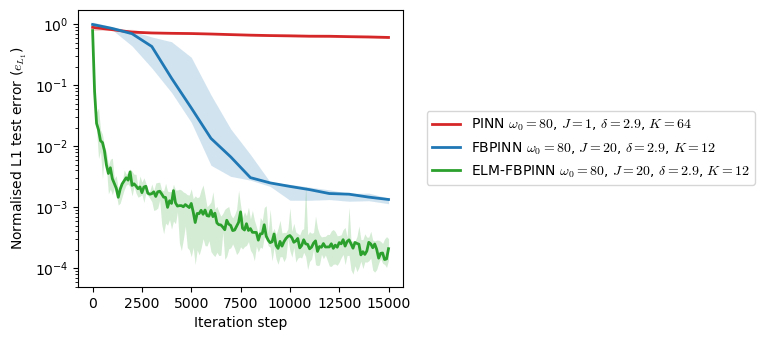

In [5]:
# CONVERGENCE TEST LOSS vs STEP

for deltas, tag2 in zip(
    ([dict(optimiser=v, delta_name="optimisers") for v in optimisers], 
    ),
     ("baseline",)
):
    data = []
    for config in apply_config_deltas(p0, deltas)[:-1]:# ignore p0 config at end of list
        (optimiser,optimiser_kwargs,run_fn) = config["optimiser"]
        network = config["network"]
        h,C,weight_scale = config["h"], config["C"], config["weight_scale"]
        w0,w,J = config["w0"], config["w"], config["J"]
        level = config["level"]
        delta_name = config["delta_name"]
    
        if run_fn == run_ELMFBPINN:
            problem=HarmonicOscillatorELM1D
        else:
            problem=HarmonicOscillator1D
        if level > 1:
            l = [1] + [J // 2**k for k in range(level-2, 0, -1)] + [J]
        else:
            l = [J]
        ns = (((C+1)*J,),)
        if run_fn != run_ELMFBPINN:
            network = FCN
        if run_fn == run_PINN:
            if delta_name != "n_hidden_units":
                C = 64
            h = 2
        lr = 1e-3
        if run_fn == run_ELMFBPINN:
            tag = f"{delta_name}-{w0}-w0_{weight_scale}-R"
        else:
            tag = f"{delta_name}-{w0}-w0"
        
        # load models
        try:
            c, model, i, ts, l1s = loader[run_fn](tag, problem, network, l, w, h, C, ns, lr, n_seeds, optimiser, optimiser_kwargs, rootdir)
        except Exception as e:
            print(tc(e, "red"))
            continue
            
        # get plot entry
        J_ = 1 if run_fn == run_PINN else (l[0] if len(l)==1 else l)
        _, icolor = optimiser_label(optimiser, optimiser_kwargs, run_fn)
        label = f"{run_label(run_fn)} $\\omega_0={w0}$, $J={J_}$, $\\delta={w}$, $K={C}$"
        data.append((label, icolor, i, ts, l1s))
    
    plt.figure(figsize=0.6*np.array([7,6]))
    for r, (label, icolor, i, ts, l1s) in enumerate(data):
        plot_l1(i, l1s, label=label, marker=None, color=colors[icolor], s=100, lw=2)
    fix_plot_convergence(legend=False)
    plt.legend(loc='center left', bbox_to_anchor=(1.05, 0.5))
    savefig(problem, f"{tag2}-convergence")
    plt.show()

15000.0 (16, 5) FBPINN_n_subdomains-80-w0_HarmonicOscillator1D_FCN_[2]-levels_2.9-overlap_1-layers_12-hidden_26-n_0.001-lr-4
15000.0 (16, 5) FBPINN_n_subdomains-80-w0_HarmonicOscillator1D_FCN_[4]-levels_2.9-overlap_1-layers_12-hidden_52-n_0.001-lr-4
15000.0 (16, 5) FBPINN_n_subdomains-80-w0_HarmonicOscillator1D_FCN_[6]-levels_2.9-overlap_1-layers_12-hidden_78-n_0.001-lr-4
15000.0 (16, 5) FBPINN_n_subdomains-80-w0_HarmonicOscillator1D_FCN_[8]-levels_2.9-overlap_1-layers_12-hidden_104-n_0.001-lr-4
15000.0 (16, 5) FBPINN_n_subdomains-80-w0_HarmonicOscillator1D_FCN_[10]-levels_2.9-overlap_1-layers_12-hidden_130-n_0.001-lr-4
15000.0 (16, 5) FBPINN_n_subdomains-80-w0_HarmonicOscillator1D_FCN_[12]-levels_2.9-overlap_1-layers_12-hidden_156-n_0.001-lr-4
15000.0 (16, 5) FBPINN_n_subdomains-80-w0_HarmonicOscillator1D_FCN_[14]-levels_2.9-overlap_1-layers_12-hidden_182-n_0.001-lr-4
15000.0 (16, 5) FBPINN_n_subdomains-80-w0_HarmonicOscillator1D_FCN_[16]-levels_2.9-overlap_1-layers_12-hidden_208-n_0.

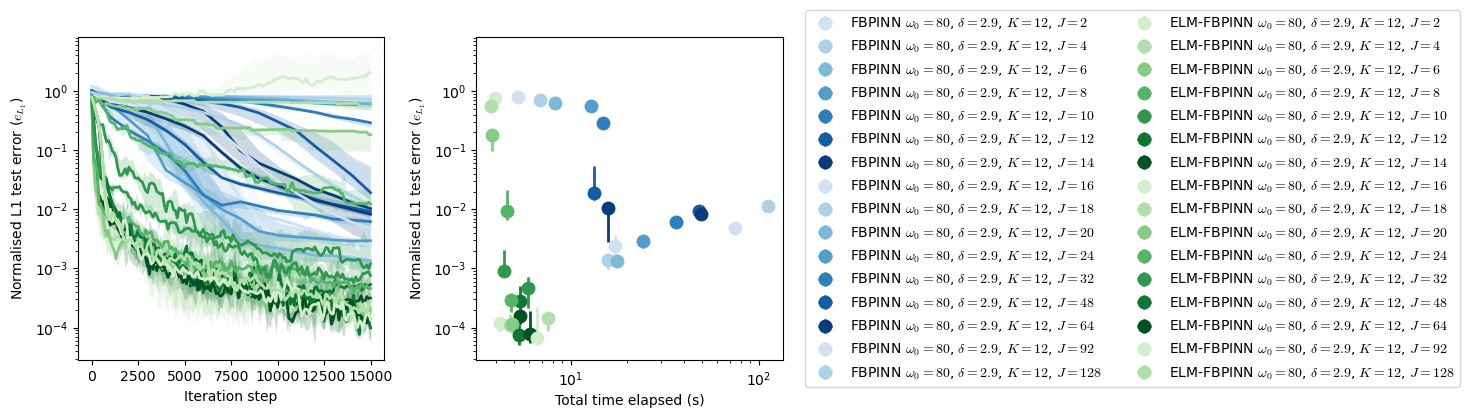

15000.0 (16, 5) PINN_n_hidden_units-80-w0_HarmonicOscillator1D_FCN_2-layers_2-hidden_60-n_0.001-lr-4
15000.0 (16, 5) PINN_n_hidden_units-80-w0_HarmonicOscillator1D_FCN_2-layers_4-hidden_100-n_0.001-lr-4
15000.0 (16, 5) PINN_n_hidden_units-80-w0_HarmonicOscillator1D_FCN_2-layers_8-hidden_180-n_0.001-lr-4
15000.0 (16, 5) PINN_n_hidden_units-80-w0_HarmonicOscillator1D_FCN_2-layers_16-hidden_340-n_0.001-lr-4
15000.0 (16, 5) PINN_n_hidden_units-80-w0_HarmonicOscillator1D_FCN_2-layers_32-hidden_660-n_0.001-lr-4
15000.0 (16, 5) PINN_n_hidden_units-80-w0_HarmonicOscillator1D_FCN_2-layers_64-hidden_1300-n_0.001-lr-4
15000.0 (16, 5) FBPINN_n_hidden_units-80-w0_HarmonicOscillator1D_FCN_[20]-levels_2.9-overlap_1-layers_2-hidden_60-n_0.001-lr-4
15000.0 (16, 5) FBPINN_n_hidden_units-80-w0_HarmonicOscillator1D_FCN_[20]-levels_2.9-overlap_1-layers_4-hidden_100-n_0.001-lr-4
15000.0 (16, 5) FBPINN_n_hidden_units-80-w0_HarmonicOscillator1D_FCN_[20]-levels_2.9-overlap_1-layers_8-hidden_180-n_0.001-lr-4
15

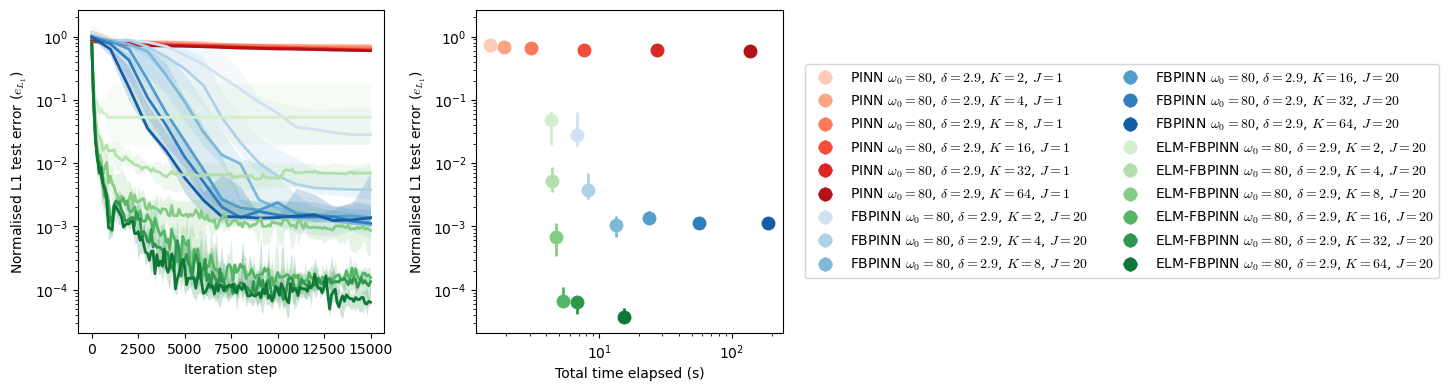

15000.0 (16, 5) FBPINN_n_subdomains_multiscale-20-w0_HarmonicOscillator1D_FCN_[10]-levels_2.9-overlap_1-layers_12-hidden_130-n_0.001-lr-4
15000.0 (16, 5) FBPINN_n_subdomains_multiscale-40-w0_HarmonicOscillator1D_FCN_[20]-levels_2.9-overlap_1-layers_12-hidden_260-n_0.001-lr-4
15000.0 (16, 5) FBPINN_n_subdomains_multiscale-80-w0_HarmonicOscillator1D_FCN_[40]-levels_2.9-overlap_1-layers_12-hidden_520-n_0.001-lr-4
15000.0 (16, 5) FBPINN_n_subdomains_multiscale-160-w0_HarmonicOscillator1D_FCN_[80]-levels_2.9-overlap_1-layers_12-hidden_1040-n_0.001-lr-4
15000.0 (16, 5) FBPINN_n_subdomains_multiscale-320-w0_HarmonicOscillator1D_FCN_[160]-levels_2.9-overlap_1-layers_12-hidden_2080-n_0.001-lr-4
15000.0 (151, 5) ELMFBPINN_n_subdomains_multiscale-20-w0_1-R_HarmonicOscillatorELM1D_ELM_[10]-levels_2.9-overlap_1-layers_12-hidden_130-n_LinearSolver-least-squares-sps_lsqr-4
15000.0 (151, 5) ELMFBPINN_n_subdomains_multiscale-40-w0_1-R_HarmonicOscillatorELM1D_ELM_[20]-levels_2.9-overlap_1-layers_12-hidd

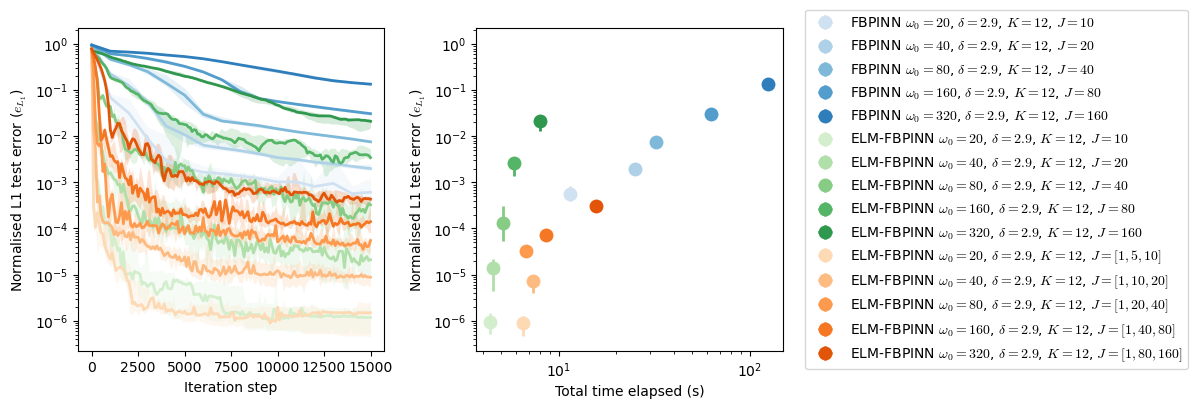

In [6]:
# FINAL TEST LOSS vs TIME (scaling)


# accuracy vs time [w0,overlap,dd,optimiser] (strong scaling & weak scaling) (weak scaling has solution plot from our solver)

for iw_deltas,tag2 in zip(
(
    [(iw, dict(J=v1, optimiser=v2, delta_name="n_subdomains")) for v2 in optimisers[1:] for (iw, v1) in enumerate(J_list)],
    [(iw, dict(C=v1, optimiser=v2, delta_name="n_hidden_units")) for v2 in optimisers for (iw, v1) in enumerate(C_list)],
    [(iw, dict(w0=v1, J=v2, optimiser=v3, level=v4, delta_name="n_subdomains_multiscale")) for (iw,v1,v2,v3,v4) in [

            # important: all scale n with J*C to keep M well-determined

            (0, 20, 10, optimisers[1], 1),# weak scaling with J
            (1, 40, 20, optimisers[1], 1),
            (2, 80, 40, optimisers[1], 1),
            (3, 160, 80, optimisers[1], 1),
            (4, 320, 160, optimisers[1], 1),

            (0, 20, 10, optimisers[2], 1),# weak scaling with J
            (1, 40, 20, optimisers[2], 1),
            (2, 80, 40, optimisers[2], 1),
            (3, 160, 80, optimisers[2], 1),
            (4, 320, 160, optimisers[2], 1),

            (0, 20, 10, optimisers[2], 3),# weak scaling with J
            (1, 40, 20, optimisers[2], 3),
            (2, 80, 40, optimisers[2], 3),
            (3, 160, 80, optimisers[2], 3),
            (4, 320, 160, optimisers[2], 3),
    ]],
), ["n-subdomains", "basis-functions", "weak"]):
    
    iws, deltas = zip(*iw_deltas)
    data = []
    for iw,config in zip(iws, apply_config_deltas(p0, deltas)[:-1]):# ignore p0 config at end of list
        (optimiser,optimiser_kwargs,run_fn) = config["optimiser"]
        network = config["network"]
        h,C,weight_scale = config["h"], config["C"], config["weight_scale"]
        w0,w,J = config["w0"], config["w"], config["J"]
        level = config["level"]
        delta_name = config["delta_name"]
    
        if run_fn == run_ELMFBPINN:
            problem=HarmonicOscillatorELM1D
        else:
            problem=HarmonicOscillator1D
        if level > 1:
            l = [1] + [J // 2**k for k in range(level-2, 0, -1)] + [J]
        else:
            l = [J]
        ns = (((C+1)*J,),)
        if run_fn != run_ELMFBPINN:
            network = FCN
        if run_fn == run_PINN:
            if delta_name != "n_hidden_units":
                C = 64
            h = 2
        lr = 1e-3
        if run_fn == run_ELMFBPINN:
            tag = f"{delta_name}-{w0}-w0_{weight_scale}-R"
        else:
            tag = f"{delta_name}-{w0}-w0"
        
        # load models
        try:
            c, model, i, ts, l1s = loader[run_fn](tag, problem, network, l, w, h, C, ns, lr, n_seeds, optimiser, optimiser_kwargs, rootdir)
        except Exception as e:
            print(tc(e, "red"))
            continue
            
        # get plot entry
        J_ = 1 if run_fn == run_PINN else (l[0] if len(l)==1 else l)
        _, icolor = optimiser_label(optimiser, optimiser_kwargs, run_fn)
        if len(l)>1: icolor=1
        label = f"{run_label(run_fn)} $\\omega_0={w0}$, $\\delta={w}$, $K={C}$, $J={J_}$"
        data.append((label, icolor, iw%7, i, ts, l1s))
    
    
    plt.figure(figsize=0.7*np.array([13,6]))
    
    plt.subplot(1,2,1)
    for label, icolor, iw, i, ts, l1s in data:
        plot_l1(i, l1s, label=label, marker=None, color=colorss[icolor][iw], s=100, lw=2)
    fix_plot_convergence(legend=False)
    ylim = plt.ylim()
    mi = min([d[5][2].min() for d in data])# min l1n mi
    ylim=(max(mi/3,ylim[0]),min(ylim[1], 1e1))
    plt.ylim(ylim)
    
    plt.subplot(1,2,2)
    for label, icolor, iw, i, ts, l1s in data:
        scatter_l1(ts, l1s, label=label, marker="o", color=colorss[icolor][iw], s=10, lw=2)
    fix_plot_scaling()
    plt.legend(loc='center left', bbox_to_anchor=(1.05, 0.5),
               ncol=int(np.ceil(len(plt.gca().get_legend_handles_labels()[0]) / 16)))
    plt.ylim(ylim)
    
    plt.subplots_adjust(wspace=0.3)
    savefig(problem, f"{tag2}-scaling")
    plt.show()

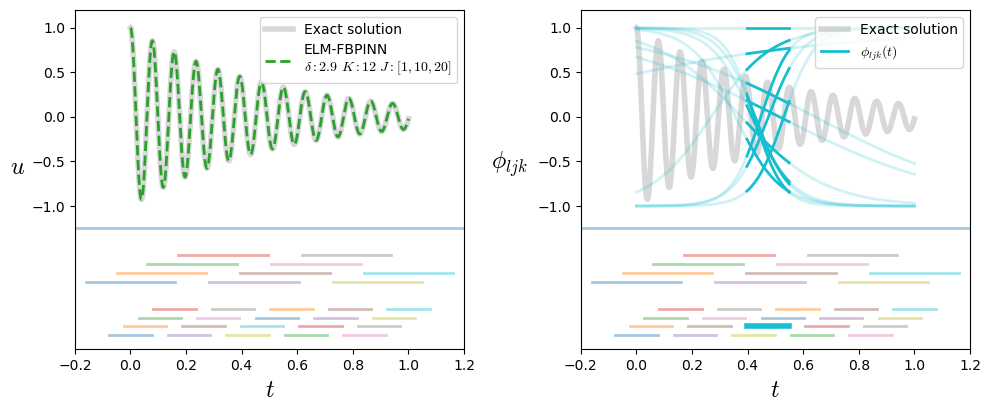

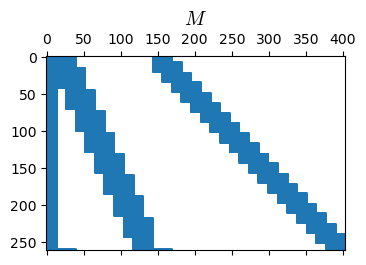

In [7]:
# BASE CASE PLOTS

(optimiser,optimiser_kwargs,run_fn) = p0["optimiser"]
network = p0["network"]
h,C,weight_scale = p0["h"], p0["C"], p0["weight_scale"]
w0,w,J = p0["w0"], p0["w"], p0["J"]
#level = p0["level"]
#delta_name = p0["delta_name"]
level = 3
delta_name = "decomposition_level"

tag = f"{delta_name}-{w0}-w0_{weight_scale}-R"
problem=HarmonicOscillatorELM1D
if level > 1:
    l = [1] + [J // 2**k for k in range(level-2, 0, -1)] + [J]
else:
    l = [J]
ns = (((C+1)*J,),)
n_test = (50*J,)
lr=1e-3

c, model, i, t, l1n = load_ELMFBPINN_(tag, problem, network, l, w, h, C, ns, lr, seed, optimiser, optimiser_kwargs, rootdir)
label = f"{run_label(run_fn)}\n$\\delta:{w}$ $K:{C}$ $J:{l}$"

# get exact solution
u_exact = exact_solution(c, model)
u = FBPINN_solution(c, model)
t = np.linspace(0,1,u_exact.shape[0])

# get basis functions
all_params = model[1]
x = t.reshape(n_test+(1,))
domain, problem, decomposition = c.domain, c.problem, c.decomposition
def basis_fn(all_params, x, norm_fn, window_fn):
    w = window_fn(all_params, x)
    x = norm_fn(all_params, x)
    x = c.network.basis_fn(all_params, x)
    return x
d = all_params
f = {t_k: {cl_k: {k: jax.tree_util.tree_map(lambda p: 0, d[t_k][cl_k][k]) if k=="subdomain" else jax.tree_util.tree_map(lambda p: None, d[t_k][cl_k][k])
    for k in d[t_k][cl_k]}
    for cl_k in d[t_k]}
    for t_k in ["static", "trainable"]}
b = jax.vmap(jax.vmap(basis_fn, in_axes=(f,None,None,None)), in_axes=(None, 0, None, None))(
    all_params, x, decomposition.norm_fn, decomposition.window_fn)# (N, J, C)

# get domain decomposition
xss = [xs[0] for xs in c.decomposition_init_kwargs["subdomain_xss"]]
wss = [ws[0] for ws in c.decomposition_init_kwargs["subdomain_wss"]]

# PLOT solution & DD
plt.figure(figsize=0.55*np.array([21,8]))

plt.subplot(1,2,1)
plt.plot(t, u_exact, color="tab:grey", lw=4, alpha=0.3, label="Exact solution")
plt.plot(t, u, "--", color="tab:green", lw=2, label=label)

for il, (xs, ws) in enumerate(zip(xss, wss)):
    for j,(x_, w_) in enumerate(zip(xs, ws)):
        plt.plot([x_-(w_/2), x_+(w_/2)], [(j%4)/10 - 1.25 -il*0.6, (j%4)/10 - 1.25 -il*0.6],
                lw=2, alpha=0.4, color=colors[j])
    plt.xlabel("$t$", fontsize="xx-large")
    plt.ylabel("$u$", fontsize="xx-large", rotation=0, labelpad=10)

plt.xlim(-0.2, 1.2)
plt.ylim(-2.6,1.2)
plt.yticks([-1,-0.5,0,0.5,1])
plt.legend()

# PLOT basis & DD

plt.subplot(1,2,2)
plt.plot(t, u_exact, color="tab:grey", lw=4, alpha=0.3, label="Exact solution")

for il, (xs, ws) in enumerate(zip(xss, wss)):
    for j,(x_, w_) in enumerate(zip(xs, ws)):
        plt.plot([x_-(w_/2), x_+(w_/2)], [(j%4)/10 - 1.25 -il*0.6, (j%4)/10 - 1.25 -il*0.6],
                lw=(4 if j==9 and il==2 else 2), alpha = (1 if j==9 and il==2 else 0.4), color=colors[j])
    plt.xlabel("$t$", fontsize="xx-large")
    plt.ylabel("$\\phi_{ljk}$", fontsize="xx-large", rotation=0, labelpad=20)

j, xs, ws = -11, xss[-1], wss[-1]
for k in range(b.shape[2]):
    fl = (x < (xs-ws/2)[j])[:,0]
    fm = ((x >= (xs-ws/2)[j]) & (x <= (xs+ws/2)[j]))[:,0]
    fr = (x > (xs+ws/2)[j])[:,0]
    plt.plot(x[fl], b[fl,j,k], color=colors[len(xs)+j], alpha=0.2, lw=2)
    plt.plot(x[fm], b[fm,j,k], color=colors[len(xs)+j], lw=2, label="$\\phi_{ljk}(t)$" if k == 0 else None)
    plt.plot(x[fr], b[fr,j,k], color=colors[len(xs)+j], alpha=0.2, lw=2)
plt.xlim(-0.2, 1.2)
plt.ylim(-2.6,1.2)
plt.yticks([-1,-0.5,0,0.5,1])
plt.legend(loc="upper right")

plt.subplots_adjust(wspace=0.3)
savefig(problem, "solution-basis")
plt.show()

# PLOT spectra and sparse matrix
M = sps.load_npz(f"{rootdir}/summaries/{c.run}/M.npz")

plt.figure(figsize=0.55*np.array([7,6]))
plot_sparse(M, "$M$", colors[0])
savefig(problem, "matrix")
plt.show()

# 2D Multiscale Laplace

In [8]:
J_list = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20]
C_list = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20]
levels = [1, 2, 3, 4]

p0 = dict(# base model params
    optimiser=optimisers[-1],# default optimiser
    network=ELM,# network
    h=1,# number of hidden layers
    C=16,# number of hidden units
    weight_scale=1,# weight scaling for network init
    n_omegas=4,# oscillator frequency
    w=2.9,# subdomain overlap
    J=16,# number of subdomains
    level=1,# number of levels for multilevel decomposition
    delta_name="p0",
    )

In [9]:
# TABLES

for deltas, tag2 in zip(
    (
    [dict(optimiser=v, delta_name="optimisers") for v in optimisers],
    [dict(J=v1, optimiser=v2, delta_name="n_subdomains")
         for v2 in optimisers[1:] for v1 in J_list],
    [dict(C=v1, optimiser=v2, delta_name="n_hidden_units")
         for v2 in optimisers for v1 in C_list],
    [dict(n_omegas=v1, J=v2, optimiser=v3, level=v4, delta_name="n_subdomains_multiscale")
         for v1, v2, v3, v4 in [

            # important: all scale n with J*C to keep M well-determined

            (1, 4, optimisers[1], 1),# weak scaling with J
            (2, 8, optimisers[1], 1),
            (3, 12, optimisers[1], 1),
            (4, 16, optimisers[1], 1),
            (5, 20, optimisers[1], 1),
            (6, 24, optimisers[1], 1),
            (7, 28, optimisers[1], 1),

            (1, 4, optimisers[2], 1),# weak scaling with J
            (2, 8, optimisers[2], 1),
            (3, 12, optimisers[2], 1),
            (4, 16, optimisers[2], 1),
            (5, 20, optimisers[2], 1),
            (6, 24, optimisers[2], 1),
            (7, 28, optimisers[2], 1),

            (1, 4, optimisers[2], 3),# weak scaling with J
            (2, 8, optimisers[2], 3),
            (3, 12, optimisers[2], 3),
            (4, 16, optimisers[2], 3),
            (5, 20, optimisers[2], 3),
            (6, 24, optimisers[2], 3),
            (7, 28, optimisers[2], 3),
    ]],
    ),
    ("baseline", "n-subdomains", "basis-functions", "weak")
):
    rows = []
    for config in apply_config_deltas(p0, deltas)[:-1]:# ignore p0 config at end of list
        (optimiser,optimiser_kwargs,run_fn) = config["optimiser"]
        network = config["network"]
        h,C,weight_scale = config["h"], config["C"], config["weight_scale"]
        n_omegas,w,J = config["n_omegas"], config["w"], config["J"]
        level = config["level"]
        delta_name = config["delta_name"]
    
        if run_fn == run_ELMFBPINN:
            problem=LaplaceELM2D_multiscale
        else:
            problem=Laplace2D_multiscale
        if level > 1:
            l = [1] + [J // 2**k for k in range(level-2, 0, -1)] + [J]
        else:
            l = [J]
        ns = ((int(np.ceil(np.sqrt((C+1))))*J, int(np.ceil(np.sqrt((C+1))))*J),)
        if run_fn != run_ELMFBPINN:
            network = FCN
        if run_fn == run_PINN:
            if delta_name != "n_hidden_units":
                C = 64
            h = 2
        lr = 1e-3
        if run_fn == run_ELMFBPINN:
            tag = f"{delta_name}-{n_omegas}-n_omegas_{weight_scale}-R"
        else:
            tag = f"{delta_name}-{n_omegas}-n_omegas"
        
        # load models
        try:
            c, model, i, ts, l1s = loader[run_fn](tag, problem, network, l, w, h, C, ns, lr, n_seeds, optimiser, optimiser_kwargs, rootdir)
        except Exception as e:
            print(tc(e, "red"))
            continue
            
        # get condition number
        if run_fn == run_ELMFBPINN:
            # load save_results run
            _c, *_ = load_ELMFBPINN_(tag, problem, network, l, w, h, C, ns, lr, seed, optimiser, optimiser_kwargs, rootdir)
            info = load_npz(f"{rootdir}summaries/{_c.run}/info.npz")
            Mcn = f"{cn(rootdir, _c, "M")[0]:.1e}"
        else:
            Mcn = "N/A"
        
        # get other entries
        J_ = 1 if run_fn == run_PINN else (l[0] if len(l)==1 else l)
        op_label,_ = optimiser_label(optimiser, optimiser_kwargs, run_fn)
        loss = compact_sci(l1s[-3], l1s[-1]-l1s[-2])# min median +/- sd
        t = compact_sci(ts[0][-1], ts[1][-1])# mean +/- sd
        
        rows.append([run_label(run_fn), (n_omegas,J_), (h,C), w,
                     Mcn, 
                     op_label, loss, t])
    
    columns = ["Model", "$(n_{\\omega},J)$", "$(h,K)$", "$\\delta$",
               "$\\kappa(M)$", 
               "Optimiser", "$e_{L_1}$", "Time (s)"]
    
    s = make_latex_tabular(columns, rows)
    savetex(s, problem, tag2)
    print(s)
    display(make_latex_array(columns, rows))

15000.0 (16, 5) PINN_optimisers-4-n_omegas_Laplace2D_multiscale_FCN_2-layers_64-hidden_80-n_0.001-lr-4
15000.0 (16, 5) FBPINN_optimisers-4-n_omegas_Laplace2D_multiscale_FCN_[16]-levels_2.9-overlap_1-layers_16-hidden_80-n_0.001-lr-4
15000.0 (151, 5) ELMFBPINN_optimisers-4-n_omegas_1-R_LaplaceELM2D_multiscale_ELM_[16]-levels_2.9-overlap_1-layers_16-hidden_80-n_LinearSolver-least-squares-sps_lsqr-4
Loading cached svals for M
\begin{tabular}{cccccccc}
\toprule
Model & $(n_{\omega},J)$ & $(h,K)$ & $\delta$ & $\kappa(M)$ & Optimiser & $e_{L_1}$ & Time (s) \\
\midrule
PINN & (4, 1) & (2, 64) & 2.9 & N/A & Adam & 8.1$\pm$38.4e-02 & 1.8$\pm$0.0e+03 \\
FBPINN & (4, 16) & (1, 16) & 2.9 & N/A & Adam & 1.8$\pm$0.4e-03 & 2.4$\pm$0.0e+03 \\
ELM-FBPINN & (4, 16) & (1, 16) & 2.9 & 1.4e+09 & LSQR & 3.8$\pm$1.2e-03 & 6.2$\pm$0.0e+01 \\
\bottomrule
\end{tabular}



<IPython.core.display.Latex object>

15000.0 (16, 5) FBPINN_n_subdomains-4-n_omegas_Laplace2D_multiscale_FCN_[2]-levels_2.9-overlap_1-layers_16-hidden_10-n_0.001-lr-4
15000.0 (16, 5) FBPINN_n_subdomains-4-n_omegas_Laplace2D_multiscale_FCN_[4]-levels_2.9-overlap_1-layers_16-hidden_20-n_0.001-lr-4
15000.0 (16, 5) FBPINN_n_subdomains-4-n_omegas_Laplace2D_multiscale_FCN_[6]-levels_2.9-overlap_1-layers_16-hidden_30-n_0.001-lr-4
15000.0 (16, 5) FBPINN_n_subdomains-4-n_omegas_Laplace2D_multiscale_FCN_[8]-levels_2.9-overlap_1-layers_16-hidden_40-n_0.001-lr-4
15000.0 (16, 5) FBPINN_n_subdomains-4-n_omegas_Laplace2D_multiscale_FCN_[10]-levels_2.9-overlap_1-layers_16-hidden_50-n_0.001-lr-4
15000.0 (16, 5) FBPINN_n_subdomains-4-n_omegas_Laplace2D_multiscale_FCN_[12]-levels_2.9-overlap_1-layers_16-hidden_60-n_0.001-lr-4
15000.0 (16, 5) FBPINN_n_subdomains-4-n_omegas_Laplace2D_multiscale_FCN_[14]-levels_2.9-overlap_1-layers_16-hidden_70-n_0.001-lr-4
15000.0 (16, 5) FBPINN_n_subdomains-4-n_omegas_Laplace2D_multiscale_FCN_[16]-levels_2.9

<IPython.core.display.Latex object>

15000.0 (16, 5) PINN_n_hidden_units-4-n_omegas_Laplace2D_multiscale_FCN_2-layers_2-hidden_32-n_0.001-lr-4
15000.0 (16, 5) PINN_n_hidden_units-4-n_omegas_Laplace2D_multiscale_FCN_2-layers_4-hidden_48-n_0.001-lr-4
15000.0 (16, 5) PINN_n_hidden_units-4-n_omegas_Laplace2D_multiscale_FCN_2-layers_6-hidden_48-n_0.001-lr-4
15000.0 (16, 5) PINN_n_hidden_units-4-n_omegas_Laplace2D_multiscale_FCN_2-layers_8-hidden_48-n_0.001-lr-4
15000.0 (16, 5) PINN_n_hidden_units-4-n_omegas_Laplace2D_multiscale_FCN_2-layers_10-hidden_64-n_0.001-lr-4
15000.0 (16, 5) PINN_n_hidden_units-4-n_omegas_Laplace2D_multiscale_FCN_2-layers_12-hidden_64-n_0.001-lr-4
15000.0 (16, 5) PINN_n_hidden_units-4-n_omegas_Laplace2D_multiscale_FCN_2-layers_14-hidden_64-n_0.001-lr-4
15000.0 (16, 5) PINN_n_hidden_units-4-n_omegas_Laplace2D_multiscale_FCN_2-layers_16-hidden_80-n_0.001-lr-4
15000.0 (16, 5) PINN_n_hidden_units-4-n_omegas_Laplace2D_multiscale_FCN_2-layers_18-hidden_80-n_0.001-lr-4
15000.0 (16, 5) PINN_n_hidden_units-4-n_o

/var/tmp/pbs.2766715.pbs-7/ipykernel_1098166/4178613413.py:217: RuntimeWarning: divide by zero encountered in scalar divide
  cn_val = svals[0] / svals[-1]
/var/tmp/pbs.2766715.pbs-7/ipykernel_1098166/4178613413.py:224: RuntimeWarning: divide by zero encountered in scalar divide
  cn_val = svals[0] / svals[-1]


still inf, adding eps...
15000.0 (151, 5) ELMFBPINN_n_hidden_units-4-n_omegas_1-R_LaplaceELM2D_multiscale_ELM_[16]-levels_2.9-overlap_1-layers_10-hidden_64-n_LinearSolver-least-squares-sps_lsqr-4
Loading cached svals for M
15000.0 (151, 5) ELMFBPINN_n_hidden_units-4-n_omegas_1-R_LaplaceELM2D_multiscale_ELM_[16]-levels_2.9-overlap_1-layers_12-hidden_64-n_LinearSolver-least-squares-sps_lsqr-4
Loading cached svals for M
15000.0 (151, 5) ELMFBPINN_n_hidden_units-4-n_omegas_1-R_LaplaceELM2D_multiscale_ELM_[16]-levels_2.9-overlap_1-layers_14-hidden_64-n_LinearSolver-least-squares-sps_lsqr-4
Loading cached svals for M
15000.0 (151, 5) ELMFBPINN_n_hidden_units-4-n_omegas_1-R_LaplaceELM2D_multiscale_ELM_[16]-levels_2.9-overlap_1-layers_16-hidden_80-n_LinearSolver-least-squares-sps_lsqr-4
Loading cached svals for M
15000.0 (151, 5) ELMFBPINN_n_hidden_units-4-n_omegas_1-R_LaplaceELM2D_multiscale_ELM_[16]-levels_2.9-overlap_1-layers_18-hidden_80-n_LinearSolver-least-squares-sps_lsqr-4
Loading cach

<IPython.core.display.Latex object>

15000.0 (16, 5) FBPINN_n_subdomains_multiscale-1-n_omegas_Laplace2D_multiscale_FCN_[4]-levels_2.9-overlap_1-layers_16-hidden_20-n_0.001-lr-4
15000.0 (16, 5) FBPINN_n_subdomains_multiscale-2-n_omegas_Laplace2D_multiscale_FCN_[8]-levels_2.9-overlap_1-layers_16-hidden_40-n_0.001-lr-4
15000.0 (16, 5) FBPINN_n_subdomains_multiscale-3-n_omegas_Laplace2D_multiscale_FCN_[12]-levels_2.9-overlap_1-layers_16-hidden_60-n_0.001-lr-4
15000.0 (16, 5) FBPINN_n_subdomains_multiscale-4-n_omegas_Laplace2D_multiscale_FCN_[16]-levels_2.9-overlap_1-layers_16-hidden_80-n_0.001-lr-4
15000.0 (16, 5) FBPINN_n_subdomains_multiscale-5-n_omegas_Laplace2D_multiscale_FCN_[20]-levels_2.9-overlap_1-layers_16-hidden_100-n_0.001-lr-4
15000.0 (16, 5) FBPINN_n_subdomains_multiscale-6-n_omegas_Laplace2D_multiscale_FCN_[24]-levels_2.9-overlap_1-layers_16-hidden_120-n_0.001-lr-4
15000.0 (16, 5) FBPINN_n_subdomains_multiscale-7-n_omegas_Laplace2D_multiscale_FCN_[28]-levels_2.9-overlap_1-layers_16-hidden_140-n_0.001-lr-4
15000

<IPython.core.display.Latex object>

15000.0 (16, 5) PINN_optimisers-4-n_omegas_Laplace2D_multiscale_FCN_2-layers_64-hidden_80-n_0.001-lr-4
15000.0 (16, 5) FBPINN_optimisers-4-n_omegas_Laplace2D_multiscale_FCN_[16]-levels_2.9-overlap_1-layers_16-hidden_80-n_0.001-lr-4
15000.0 (151, 5) ELMFBPINN_optimisers-4-n_omegas_1-R_LaplaceELM2D_multiscale_ELM_[16]-levels_2.9-overlap_1-layers_16-hidden_80-n_LinearSolver-least-squares-sps_lsqr-4


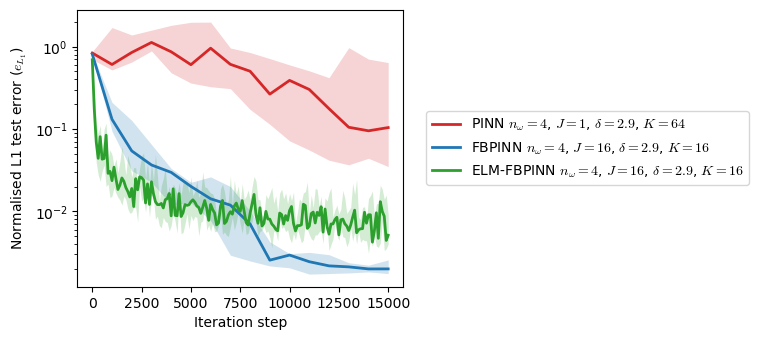

In [10]:
# CONVERGENCE TEST LOSS vs STEP

for deltas, tag2 in zip(
    ([dict(optimiser=v, delta_name="optimisers") for v in optimisers], 
    ),
     ("baseline",)
):
    data = []
    for config in apply_config_deltas(p0, deltas)[:-1]:# ignore p0 config at end of list
        (optimiser,optimiser_kwargs,run_fn) = config["optimiser"]
        network = config["network"]
        h,C,weight_scale = config["h"], config["C"], config["weight_scale"]
        n_omegas,w,J = config["n_omegas"], config["w"], config["J"]
        level = config["level"]
        delta_name = config["delta_name"]
    
        if run_fn == run_ELMFBPINN:
            problem=LaplaceELM2D_multiscale
        else:
            problem=Laplace2D_multiscale
        if level > 1:
            l = [1] + [J // 2**k for k in range(level-2, 0, -1)] + [J]
        else:
            l = [J]
        ns = ((int(np.ceil(np.sqrt((C+1))))*J, int(np.ceil(np.sqrt((C+1))))*J),)
        if run_fn != run_ELMFBPINN:
            network = FCN
        if run_fn == run_PINN:
            if delta_name != "n_hidden_units":
                C = 64
            h = 2
        lr = 1e-3
        if run_fn == run_ELMFBPINN:
            tag = f"{delta_name}-{n_omegas}-n_omegas_{weight_scale}-R"
        else:
            tag = f"{delta_name}-{n_omegas}-n_omegas"
        
        # load models
        try:
            c, model, i, ts, l1s = loader[run_fn](tag, problem, network, l, w, h, C, ns, lr, n_seeds, optimiser, optimiser_kwargs, rootdir)
        except Exception as e:
            print(tc(e, "red"))
            continue
            
        # get plot entry
        J_ = 1 if run_fn == run_PINN else (l[0] if len(l)==1 else l)
        _, icolor = optimiser_label(optimiser, optimiser_kwargs, run_fn)
        label = f"{run_label(run_fn)} $n_{{\\omega}}={n_omegas}$, $J={J_}$, $\\delta={w}$, $K={C}$"
        data.append((label, icolor, i, ts, l1s))
    
    plt.figure(figsize=0.6*np.array([7,6]))
    for r, (label, icolor, i, ts, l1s) in enumerate(data):
        plot_l1(i, l1s, label=label, marker=None, color=colors[icolor], s=100, lw=2)
    fix_plot_convergence(legend=False)
    plt.legend(loc='center left', bbox_to_anchor=(1.05, 0.5))
    savefig(problem, f"{tag2}-convergence")
    plt.show()

15000.0 (16, 5) FBPINN_n_subdomains-4-n_omegas_Laplace2D_multiscale_FCN_[2]-levels_2.9-overlap_1-layers_16-hidden_10-n_0.001-lr-4
15000.0 (16, 5) FBPINN_n_subdomains-4-n_omegas_Laplace2D_multiscale_FCN_[4]-levels_2.9-overlap_1-layers_16-hidden_20-n_0.001-lr-4
15000.0 (16, 5) FBPINN_n_subdomains-4-n_omegas_Laplace2D_multiscale_FCN_[6]-levels_2.9-overlap_1-layers_16-hidden_30-n_0.001-lr-4
15000.0 (16, 5) FBPINN_n_subdomains-4-n_omegas_Laplace2D_multiscale_FCN_[8]-levels_2.9-overlap_1-layers_16-hidden_40-n_0.001-lr-4
15000.0 (16, 5) FBPINN_n_subdomains-4-n_omegas_Laplace2D_multiscale_FCN_[10]-levels_2.9-overlap_1-layers_16-hidden_50-n_0.001-lr-4
15000.0 (16, 5) FBPINN_n_subdomains-4-n_omegas_Laplace2D_multiscale_FCN_[12]-levels_2.9-overlap_1-layers_16-hidden_60-n_0.001-lr-4
15000.0 (16, 5) FBPINN_n_subdomains-4-n_omegas_Laplace2D_multiscale_FCN_[14]-levels_2.9-overlap_1-layers_16-hidden_70-n_0.001-lr-4
15000.0 (16, 5) FBPINN_n_subdomains-4-n_omegas_Laplace2D_multiscale_FCN_[16]-levels_2.9

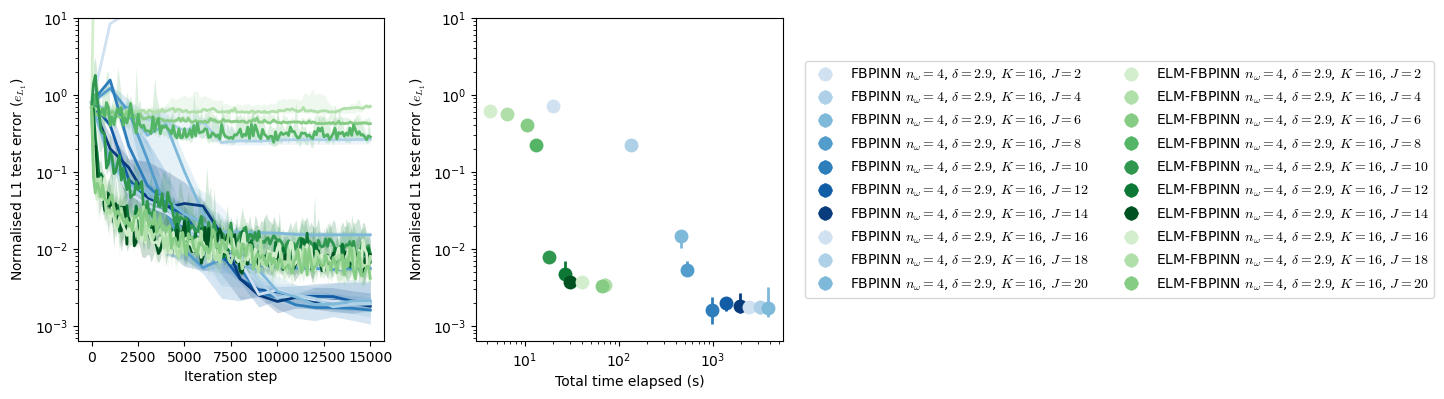

15000.0 (16, 5) PINN_n_hidden_units-4-n_omegas_Laplace2D_multiscale_FCN_2-layers_2-hidden_32-n_0.001-lr-4
15000.0 (16, 5) PINN_n_hidden_units-4-n_omegas_Laplace2D_multiscale_FCN_2-layers_4-hidden_48-n_0.001-lr-4
15000.0 (16, 5) PINN_n_hidden_units-4-n_omegas_Laplace2D_multiscale_FCN_2-layers_6-hidden_48-n_0.001-lr-4
15000.0 (16, 5) PINN_n_hidden_units-4-n_omegas_Laplace2D_multiscale_FCN_2-layers_8-hidden_48-n_0.001-lr-4
15000.0 (16, 5) PINN_n_hidden_units-4-n_omegas_Laplace2D_multiscale_FCN_2-layers_10-hidden_64-n_0.001-lr-4
15000.0 (16, 5) PINN_n_hidden_units-4-n_omegas_Laplace2D_multiscale_FCN_2-layers_12-hidden_64-n_0.001-lr-4
15000.0 (16, 5) PINN_n_hidden_units-4-n_omegas_Laplace2D_multiscale_FCN_2-layers_14-hidden_64-n_0.001-lr-4
15000.0 (16, 5) PINN_n_hidden_units-4-n_omegas_Laplace2D_multiscale_FCN_2-layers_16-hidden_80-n_0.001-lr-4
15000.0 (16, 5) PINN_n_hidden_units-4-n_omegas_Laplace2D_multiscale_FCN_2-layers_18-hidden_80-n_0.001-lr-4
15000.0 (16, 5) PINN_n_hidden_units-4-n_o

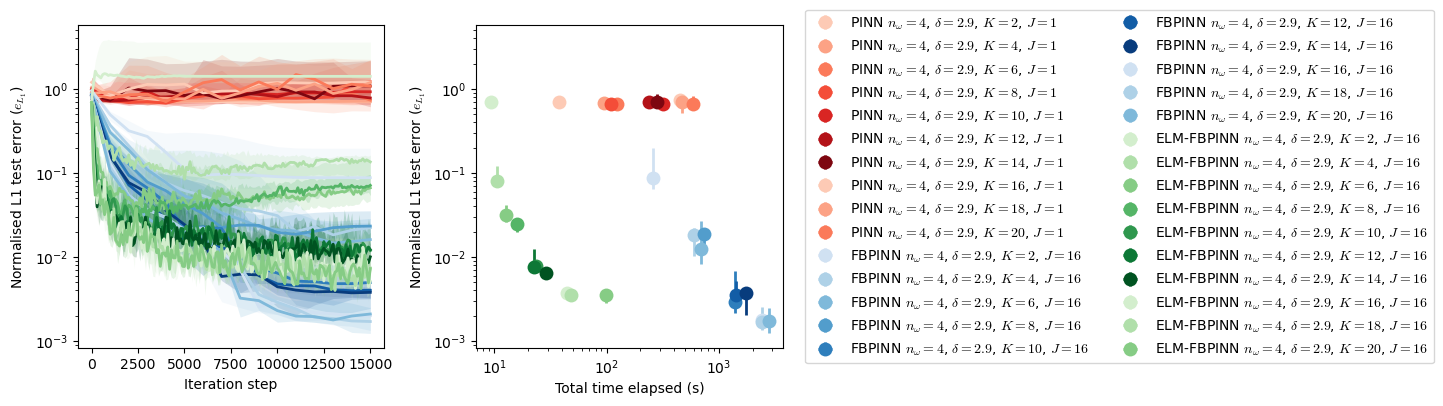

15000.0 (16, 5) FBPINN_n_subdomains_multiscale-1-n_omegas_Laplace2D_multiscale_FCN_[4]-levels_2.9-overlap_1-layers_16-hidden_20-n_0.001-lr-4
15000.0 (16, 5) FBPINN_n_subdomains_multiscale-2-n_omegas_Laplace2D_multiscale_FCN_[8]-levels_2.9-overlap_1-layers_16-hidden_40-n_0.001-lr-4
15000.0 (16, 5) FBPINN_n_subdomains_multiscale-3-n_omegas_Laplace2D_multiscale_FCN_[12]-levels_2.9-overlap_1-layers_16-hidden_60-n_0.001-lr-4
15000.0 (16, 5) FBPINN_n_subdomains_multiscale-4-n_omegas_Laplace2D_multiscale_FCN_[16]-levels_2.9-overlap_1-layers_16-hidden_80-n_0.001-lr-4
15000.0 (16, 5) FBPINN_n_subdomains_multiscale-5-n_omegas_Laplace2D_multiscale_FCN_[20]-levels_2.9-overlap_1-layers_16-hidden_100-n_0.001-lr-4
15000.0 (16, 5) FBPINN_n_subdomains_multiscale-6-n_omegas_Laplace2D_multiscale_FCN_[24]-levels_2.9-overlap_1-layers_16-hidden_120-n_0.001-lr-4
15000.0 (16, 5) FBPINN_n_subdomains_multiscale-7-n_omegas_Laplace2D_multiscale_FCN_[28]-levels_2.9-overlap_1-layers_16-hidden_140-n_0.001-lr-4
15000

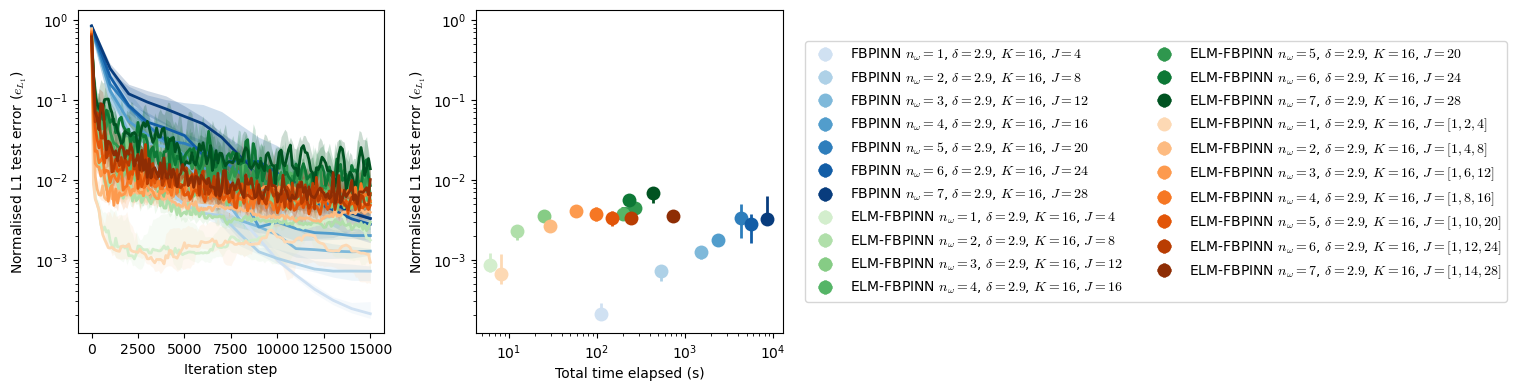

In [11]:
# FINAL TEST LOSS vs TIME (scaling)


# accuracy vs time [w0,overlap,dd,optimiser] (strong scaling & weak scaling) (weak scaling has solution plot from our solver)

for iw_deltas,tag2 in zip(
(
    [(iw, dict(J=v1, optimiser=v2, delta_name="n_subdomains")) for v2 in optimisers[1:] for (iw, v1) in enumerate(J_list)],
    [(iw, dict(C=v1, optimiser=v2, delta_name="n_hidden_units")) for v2 in optimisers for (iw, v1) in enumerate(C_list)],
    [(iw, dict(n_omegas=v1, J=v2, optimiser=v3, level=v4, delta_name="n_subdomains_multiscale")) for (iw,v1,v2,v3,v4) in [

            # important: all scale n with J*C to keep M well-determined

            (0, 1, 4, optimisers[1], 1),# weak scaling with J
            (1, 2, 8, optimisers[1], 1),
            (2, 3, 12, optimisers[1], 1),
            (3, 4, 16, optimisers[1], 1),
            (4, 5, 20, optimisers[1], 1),
            (5, 6, 24, optimisers[1], 1),
            (6, 7, 28, optimisers[1], 1),

            (0, 1, 4, optimisers[2], 1),# weak scaling with J
            (1, 2, 8, optimisers[2], 1),
            (2, 3, 12, optimisers[2], 1),
            (3, 4, 16, optimisers[2], 1),
            (4, 5, 20, optimisers[2], 1),
            (5, 6, 24, optimisers[2], 1),
            (6, 7, 28, optimisers[2], 1),

            (0, 1, 4, optimisers[2], 3),# weak scaling with J
            (1, 2, 8, optimisers[2], 3),
            (2, 3, 12, optimisers[2], 3),
            (3, 4, 16, optimisers[2], 3),
            (4, 5, 20, optimisers[2], 3),
            (5, 6, 24, optimisers[2], 3),
            (6, 7, 28, optimisers[2], 3),
    ]],
), ["n-subdomains", "basis-functions", "weak"]):
    
    iws, deltas = zip(*iw_deltas)
    data = []
    for iw,config in zip(iws, apply_config_deltas(p0, deltas)[:-1]):# ignore p0 config at end of list
        (optimiser,optimiser_kwargs,run_fn) = config["optimiser"]
        network = config["network"]
        h,C,weight_scale = config["h"], config["C"], config["weight_scale"]
        n_omegas,w,J = config["n_omegas"], config["w"], config["J"]
        level = config["level"]
        delta_name = config["delta_name"]
    
        if run_fn == run_ELMFBPINN:
            problem=LaplaceELM2D_multiscale
        else:
            problem=Laplace2D_multiscale
        if level > 1:
            l = [1] + [J // 2**k for k in range(level-2, 0, -1)] + [J]
        else:
            l = [J]
        ns = ((int(np.ceil(np.sqrt((C+1))))*J, int(np.ceil(np.sqrt((C+1))))*J),)
        if run_fn != run_ELMFBPINN:
            network = FCN
        if run_fn == run_PINN:
            if delta_name != "n_hidden_units":
                C = 64
            h = 2
        lr = 1e-3
        if run_fn == run_ELMFBPINN:
            tag = f"{delta_name}-{n_omegas}-n_omegas_{weight_scale}-R"
        else:
            tag = f"{delta_name}-{n_omegas}-n_omegas"
        
        # load models
        try:
            c, model, i, ts, l1s = loader[run_fn](tag, problem, network, l, w, h, C, ns, lr, n_seeds, optimiser, optimiser_kwargs, rootdir)
        except Exception as e:
            print(tc(e, "red"))
            continue
            
        # get plot entry
        J_ = 1 if run_fn == run_PINN else (l[0] if len(l)==1 else l)
        _, icolor = optimiser_label(optimiser, optimiser_kwargs, run_fn)
        if len(l)>1: icolor=1
        label = f"{run_label(run_fn)} $n_{{\\omega}}={n_omegas}$, $\\delta={w}$, $K={C}$, $J={J_}$"
        data.append((label, icolor, iw%7, i, ts, l1s))
    
    
    plt.figure(figsize=0.7*np.array([13,6]))
    
    plt.subplot(1,2,1)
    for label, icolor, iw, i, ts, l1s in data:
        plot_l1(i, l1s, label=label, marker=None, color=colorss[icolor][iw], s=100, lw=2)
    fix_plot_convergence(legend=False)
    ylim = plt.ylim()
    mi = min([d[5][2].min() for d in data])# min l1n mi
    ylim=(max(mi/3,ylim[0]),min(ylim[1], 1e1))
    plt.ylim(ylim)
    
    plt.subplot(1,2,2)
    for label, icolor, iw, i, ts, l1s in data:
        scatter_l1(ts, l1s, label=label, marker="o", color=colorss[icolor][iw], s=10, lw=2)
    fix_plot_scaling()
    plt.legend(loc='center left', bbox_to_anchor=(1.05, 0.5),
               ncol=int(np.ceil(len(plt.gca().get_legend_handles_labels()[0]) / 16)))
    plt.ylim(ylim)
    
    plt.subplots_adjust(wspace=0.3)
    savefig(problem, f"{tag2}-scaling")
    plt.show()

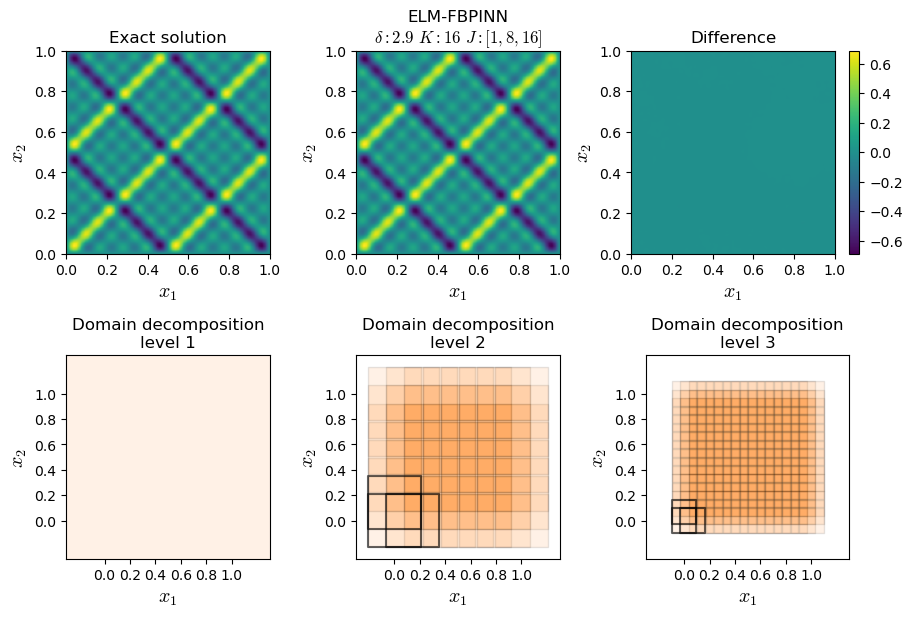

In [12]:
# BASE CASE PLOTS

(optimiser,optimiser_kwargs,run_fn) = p0["optimiser"]
network = p0["network"]
h,C,weight_scale = p0["h"], p0["C"], p0["weight_scale"]
n_omegas,w,J = p0["n_omegas"], p0["w"], p0["J"]
#level = p0["level"]
#delta_name = p0["delta_name"]
level = 3
delta_name = "decomposition_level"

tag = f"{delta_name}-{n_omegas}-n_omegas_{weight_scale}-R"
problem=LaplaceELM2D_multiscale
if level > 1:
    l = [1] + [J // 2**k for k in range(level-2, 0, -1)] + [J]
else:
    l = [J]
ns = ((int(np.ceil(np.sqrt((C+1))))*J, int(np.ceil(np.sqrt((C+1))))*J),)
n_test = (int(np.ceil(np.sqrt(30)))*J, int(np.ceil(np.sqrt(30)))*J)
lr=1e-3

c, model, i, t, l1n = load_ELMFBPINN_(tag, problem, network, l, w, h, C, ns, lr, seed, optimiser, optimiser_kwargs, rootdir)
label = f"{run_label(run_fn)}\n$\\delta:{w}$ $K:{C}$ $J:{l}$"

# get exact solution
c.n_test = (150,150)
u_exact = exact_solution(c, model)
u = FBPINN_solution(c, model)

all_params = model[1]
domain = c.domain
xmin, xmax = all_params["static"]["domain"]["xmin"], all_params["static"]["domain"]["xmax"]
xmins, xmaxs, wmins, wmaxs, *_ = all_params["static"]["decomposition"]["subdomain"]["params"]
pou = all_params["static"]["decomposition"]["subdomain"]["pou"]

# plot solution vs exact, domain decomposition, spectra

plt.figure(figsize=0.6*np.array([18.7,11]))

plt.subplot(2,3,1)
plt.title("Exact solution")
im = plt.imshow(u_exact.T, origin="lower", extent=(0,1,0,1))
fix_plot_2d_solution()
plt.xticks([0, 0.2, 0.4, 0.6, 0.8, 1])
plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1])

plt.subplot(2,3,2)
plt.title(label)
plt.imshow(u.T, origin="lower", extent=(0,1,0,1), vmin=im.get_clim()[0], vmax=im.get_clim()[1])
fix_plot_2d_solution()
plt.xticks([0, 0.2, 0.4, 0.6, 0.8, 1])
plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1])

plt.subplot(2,3,3)
plt.title("Difference")
plt.imshow((u_exact - u).T, origin="lower", extent=(0,1,0,1), vmin=im.get_clim()[0], vmax=im.get_clim()[1])
fix_plot_2d_solution()
plt.colorbar()
plt.xticks([0, 0.2, 0.4, 0.6, 0.8, 1])
plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1])

for l_ in range(level):
    xmins_ = xmins[pou[:,0]==l_]
    xmaxs_ = xmaxs[pou[:,0]==l_]
    
    plt.subplot(2,3,4+l_)
    plt.title(f"Domain decomposition\nlevel {l_+1}")
    patches, rs = [], []
    for i in range(len(xmins_)):
        patches.append(mpatches.Rectangle((xmins_[i,0],xmins_[i,1]),
                                           xmaxs_[i,0]-xmins_[i,0],
                                           xmaxs_[i,1]-xmins_[i,1],
                                         ))
        if i in [0,1,l[l_]]:
            rs.append(mpatches.Rectangle((xmins_[i,0],xmins_[i,1]),
                                          xmaxs_[i,0]-xmins_[i,0],
                                          xmaxs_[i,1]-xmins_[i,1],
                                         ))
    plt.gca().add_collection(mcoll.PatchCollection(patches,
                                                   alpha=0.1,
                                                   edgecolor="k",
                                                   facecolor="tab:orange"))
    plt.gca().add_collection(mcoll.PatchCollection(rs,
                                                   facecolor="none",
                                                   linewidth=1.5,
                                                   alpha=0.6,
                                                   edgecolor="k"))
    plt.xlim(-0.3, 1.3)
    plt.ylim(-0.3, 1.3)
    plt.xticks([0, 0.2, 0.4, 0.6, 0.8, 1])
    plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
    plt.xlabel("$x_1$", fontsize="x-large"); plt.ylabel("$x_2$", fontsize="x-large")
    plt.gca().set_aspect('equal')

plt.subplots_adjust(wspace=0, hspace=0.5)

savefig(problem, "solution")
plt.show()

# 2D Inhomogeneous Helmholtz equation

In [13]:
J_list = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20]
C_list = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20]
levels = [1, 2, 3, 4]

p0 = dict(# base model params
    optimiser=optimisers[-1],# default optimiser
    network=ELM,# network
    h=1,# number of hidden layers
    C=16,# number of hidden units
    weight_scale=1,# weight scaling for network init
    omega=8,# oscillator frequency
    w=2.9,# subdomain overlap
    J=16,# number of subdomains
    level=1,# number of levels for multilevel decomposition
    delta_name="p0",
    )

In [14]:
# TABLES

for deltas, tag2 in zip(
    (
    [dict(optimiser=v, delta_name="optimisers") for v in optimisers],
    [dict(J=v1, optimiser=v2, delta_name="n_subdomains")
         for v2 in optimisers[1:] for v1 in J_list],
    [dict(C=v1, optimiser=v2, delta_name="n_hidden_units")
         for v2 in optimisers for v1 in C_list],
    [dict(omega=v1, J=v2, optimiser=v3, level=v4, delta_name="n_subdomains_multiscale")
         for v1, v2, v3, v4 in [

            # important: all scale n with J*C to keep M well-determined

            (4, 8, optimisers[1], 1),# weak scaling with J
            (6, 12, optimisers[1], 1),
            (8, 16, optimisers[1], 1),
            (10, 20, optimisers[1], 1),
            (12, 24, optimisers[1], 1),
            (14, 28, optimisers[1], 1),
            (16, 32, optimisers[1], 1),

            (4, 8, optimisers[2], 1),# weak scaling with J
            (6, 12, optimisers[2], 1),
            (8, 16, optimisers[2], 1),
            (10, 20, optimisers[2], 1),
            (12, 24, optimisers[2], 1),
            (14, 28, optimisers[2], 1),
            (16, 32, optimisers[2], 1),

            (4, 8, optimisers[2], 3),# weak scaling with J
            (6, 12, optimisers[2], 3),
            (8, 16, optimisers[2], 3),
            (10, 20, optimisers[2], 3),
            (12, 24, optimisers[2], 3),
            (14, 28, optimisers[2], 3),
            (16, 32, optimisers[2], 3),
    ]],
    ),
    ("baseline", "n-subdomains", "basis-functions", "weak")
):
    rows = []
    for config in apply_config_deltas(p0, deltas)[:-1]:# ignore p0 config at end of list
        (optimiser,optimiser_kwargs,run_fn) = config["optimiser"]
        network = config["network"]
        h,C,weight_scale = config["h"], config["C"], config["weight_scale"]
        omega,w,J = config["omega"], config["w"], config["J"]
        level = config["level"]
        delta_name = config["delta_name"]
    
        if run_fn == run_ELMFBPINN:
            problem=HelmholtzELM2D
        else:
            problem=Helmholtz2D
        if level > 1:
            l = [1] + [J // 2**k for k in range(level-2, 0, -1)] + [J]
        else:
            l = [J]
        ns = ((int(np.ceil(np.sqrt((C+1))))*J, int(np.ceil(np.sqrt((C+1))))*J),)
        if run_fn != run_ELMFBPINN:
            network = FCN
        if run_fn == run_PINN:
            if delta_name != "n_hidden_units":
                C = 64
            h = 2
        lr = 1e-3
        if run_fn == run_ELMFBPINN:
            tag = f"{delta_name}-{omega}-omega_{weight_scale}-R"
        else:
            tag = f"{delta_name}-{omega}-omega"
        
        # load models
        try:
            c, model, i, ts, l1s = loader[run_fn](tag, problem, network, l, w, h, C, ns, lr, n_seeds, optimiser, optimiser_kwargs, rootdir)
        except Exception as e:
            print(tc(e, "red"))
            continue
            
        # get condition number
        if run_fn == run_ELMFBPINN:
            # load save_results run
            _c, *_ = load_ELMFBPINN_(tag, problem, network, l, w, h, C, ns, lr, seed, optimiser, optimiser_kwargs, rootdir)
            info = load_npz(f"{rootdir}summaries/{_c.run}/info.npz")
            Mcn = f"{cn(rootdir, _c, "M")[0]:.1e}"
        else:
            Mcn = "N/A"
        
        # get other entries
        J_ = 1 if run_fn == run_PINN else (l[0] if len(l)==1 else l)
        op_label,_ = optimiser_label(optimiser, optimiser_kwargs, run_fn)
        loss = compact_sci(l1s[-3], l1s[-1]-l1s[-2])# min median +/- sd
        t = compact_sci(ts[0][-1], ts[1][-1])# mean +/- sd
        
        rows.append([run_label(run_fn), (omega,J_), (h,C), w,
                     Mcn, 
                     op_label, loss, t])
    
    columns = ["Model", "$(\\omega,J)$", "$(h,K)$", "$\\delta$",
               "$\\kappa(M)$", 
               "Optimiser", "$e_{L_1}$", "Time (s)"]
    
    s = make_latex_tabular(columns, rows)
    savetex(s, problem, tag2)
    print(s)
    display(make_latex_array(columns, rows))

15000.0 (16, 5) PINN_optimisers-8-omega_Helmholtz2D_FCN_2-layers_64-hidden_80-n_0.001-lr-4
15000.0 (16, 5) FBPINN_optimisers-8-omega_Helmholtz2D_FCN_[16]-levels_2.9-overlap_1-layers_16-hidden_80-n_0.001-lr-4
15000.0 (151, 5) ELMFBPINN_optimisers-8-omega_1-R_HelmholtzELM2D_ELM_[16]-levels_2.9-overlap_1-layers_16-hidden_80-n_LinearSolver-least-squares-sps_lsqr-4
Loading cached svals for M
\begin{tabular}{cccccccc}
\toprule
Model & $(\omega,J)$ & $(h,K)$ & $\delta$ & $\kappa(M)$ & Optimiser & $e_{L_1}$ & Time (s) \\
\midrule
PINN & (8, 1) & (2, 64) & 2.9 & N/A & Adam & 1.8$\pm$4.8e-01 & 1.1$\pm$0.0e+03 \\
FBPINN & (8, 16) & (1, 16) & 2.9 & N/A & Adam & 2.7$\pm$0.6e-03 & 1.5$\pm$0.0e+03 \\
ELM-FBPINN & (8, 16) & (1, 16) & 2.9 & 3.7e+08 & LSQR & 1.3$\pm$0.8e-02 & 3.7$\pm$0.0e+01 \\
\bottomrule
\end{tabular}



<IPython.core.display.Latex object>

15000.0 (16, 5) FBPINN_n_subdomains-8-omega_Helmholtz2D_FCN_[2]-levels_2.9-overlap_1-layers_16-hidden_10-n_0.001-lr-4
15000.0 (16, 5) FBPINN_n_subdomains-8-omega_Helmholtz2D_FCN_[4]-levels_2.9-overlap_1-layers_16-hidden_20-n_0.001-lr-4
15000.0 (16, 5) FBPINN_n_subdomains-8-omega_Helmholtz2D_FCN_[6]-levels_2.9-overlap_1-layers_16-hidden_30-n_0.001-lr-4
15000.0 (16, 5) FBPINN_n_subdomains-8-omega_Helmholtz2D_FCN_[8]-levels_2.9-overlap_1-layers_16-hidden_40-n_0.001-lr-4
15000.0 (16, 5) FBPINN_n_subdomains-8-omega_Helmholtz2D_FCN_[10]-levels_2.9-overlap_1-layers_16-hidden_50-n_0.001-lr-4
15000.0 (16, 5) FBPINN_n_subdomains-8-omega_Helmholtz2D_FCN_[12]-levels_2.9-overlap_1-layers_16-hidden_60-n_0.001-lr-4
15000.0 (16, 5) FBPINN_n_subdomains-8-omega_Helmholtz2D_FCN_[14]-levels_2.9-overlap_1-layers_16-hidden_70-n_0.001-lr-4
15000.0 (16, 5) FBPINN_n_subdomains-8-omega_Helmholtz2D_FCN_[16]-levels_2.9-overlap_1-layers_16-hidden_80-n_0.001-lr-4
15000.0 (16, 5) FBPINN_n_subdomains-8-omega_Helmholt

<IPython.core.display.Latex object>

15000.0 (16, 5) PINN_n_hidden_units-8-omega_Helmholtz2D_FCN_2-layers_2-hidden_32-n_0.001-lr-4
15000.0 (16, 5) PINN_n_hidden_units-8-omega_Helmholtz2D_FCN_2-layers_4-hidden_48-n_0.001-lr-4
15000.0 (16, 5) PINN_n_hidden_units-8-omega_Helmholtz2D_FCN_2-layers_6-hidden_48-n_0.001-lr-4
15000.0 (16, 5) PINN_n_hidden_units-8-omega_Helmholtz2D_FCN_2-layers_8-hidden_48-n_0.001-lr-4
15000.0 (16, 5) PINN_n_hidden_units-8-omega_Helmholtz2D_FCN_2-layers_10-hidden_64-n_0.001-lr-4
15000.0 (16, 5) PINN_n_hidden_units-8-omega_Helmholtz2D_FCN_2-layers_12-hidden_64-n_0.001-lr-4
15000.0 (16, 5) PINN_n_hidden_units-8-omega_Helmholtz2D_FCN_2-layers_14-hidden_64-n_0.001-lr-4
15000.0 (16, 5) PINN_n_hidden_units-8-omega_Helmholtz2D_FCN_2-layers_16-hidden_80-n_0.001-lr-4
15000.0 (16, 5) PINN_n_hidden_units-8-omega_Helmholtz2D_FCN_2-layers_18-hidden_80-n_0.001-lr-4
15000.0 (16, 5) PINN_n_hidden_units-8-omega_Helmholtz2D_FCN_2-layers_20-hidden_80-n_0.001-lr-4
15000.0 (16, 5) FBPINN_n_hidden_units-8-omega_Helmholt

<IPython.core.display.Latex object>

15000.0 (16, 5) FBPINN_n_subdomains_multiscale-4-omega_Helmholtz2D_FCN_[8]-levels_2.9-overlap_1-layers_16-hidden_40-n_0.001-lr-4
15000.0 (16, 5) FBPINN_n_subdomains_multiscale-6-omega_Helmholtz2D_FCN_[12]-levels_2.9-overlap_1-layers_16-hidden_60-n_0.001-lr-4
15000.0 (16, 5) FBPINN_n_subdomains_multiscale-8-omega_Helmholtz2D_FCN_[16]-levels_2.9-overlap_1-layers_16-hidden_80-n_0.001-lr-4
15000.0 (16, 5) FBPINN_n_subdomains_multiscale-10-omega_Helmholtz2D_FCN_[20]-levels_2.9-overlap_1-layers_16-hidden_100-n_0.001-lr-4
15000.0 (16, 5) FBPINN_n_subdomains_multiscale-12-omega_Helmholtz2D_FCN_[24]-levels_2.9-overlap_1-layers_16-hidden_120-n_0.001-lr-4
15000.0 (16, 5) FBPINN_n_subdomains_multiscale-14-omega_Helmholtz2D_FCN_[28]-levels_2.9-overlap_1-layers_16-hidden_140-n_0.001-lr-4
15000.0 (16, 5) FBPINN_n_subdomains_multiscale-16-omega_Helmholtz2D_FCN_[32]-levels_2.9-overlap_1-layers_16-hidden_160-n_0.001-lr-4
15000.0 (151, 5) ELMFBPINN_n_subdomains_multiscale-4-omega_1-R_HelmholtzELM2D_ELM_[

<IPython.core.display.Latex object>

15000.0 (16, 5) PINN_optimisers-8-omega_Helmholtz2D_FCN_2-layers_64-hidden_80-n_0.001-lr-4
15000.0 (16, 5) FBPINN_optimisers-8-omega_Helmholtz2D_FCN_[16]-levels_2.9-overlap_1-layers_16-hidden_80-n_0.001-lr-4
15000.0 (151, 5) ELMFBPINN_optimisers-8-omega_1-R_HelmholtzELM2D_ELM_[16]-levels_2.9-overlap_1-layers_16-hidden_80-n_LinearSolver-least-squares-sps_lsqr-4


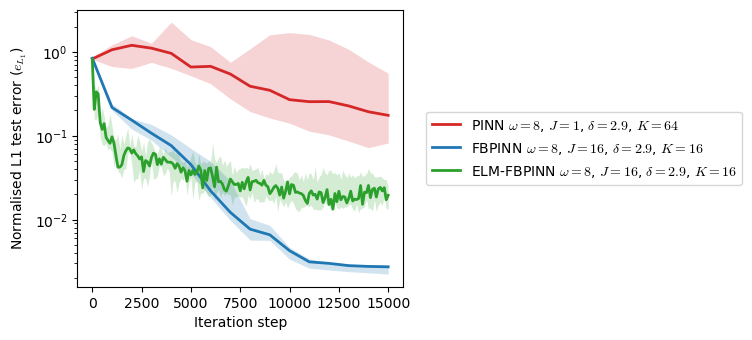

In [15]:
# CONVERGENCE TEST LOSS vs STEP

for deltas, tag2 in zip(
    ([dict(optimiser=v, delta_name="optimisers") for v in optimisers], 
    ),
     ("baseline",)
):
    data = []
    for config in apply_config_deltas(p0, deltas)[:-1]:# ignore p0 config at end of list
        (optimiser,optimiser_kwargs,run_fn) = config["optimiser"]
        network = config["network"]
        h,C,weight_scale = config["h"], config["C"], config["weight_scale"]
        omega,w,J = config["omega"], config["w"], config["J"]
        level = config["level"]
        delta_name = config["delta_name"]
    
        if run_fn == run_ELMFBPINN:
            problem=HelmholtzELM2D
        else:
            problem=Helmholtz2D
        if level > 1:
            l = [1] + [J // 2**k for k in range(level-2, 0, -1)] + [J]
        else:
            l = [J]
        ns = ((int(np.ceil(np.sqrt((C+1))))*J, int(np.ceil(np.sqrt((C+1))))*J),)
        if run_fn != run_ELMFBPINN:
            network = FCN
        if run_fn == run_PINN:
            if delta_name != "n_hidden_units":
                C = 64
            h = 2
        lr = 1e-3
        if run_fn == run_ELMFBPINN:
            tag = f"{delta_name}-{omega}-omega_{weight_scale}-R"
        else:
            tag = f"{delta_name}-{omega}-omega"
        
        # load models
        try:
            c, model, i, ts, l1s = loader[run_fn](tag, problem, network, l, w, h, C, ns, lr, n_seeds, optimiser, optimiser_kwargs, rootdir)
        except Exception as e:
            print(tc(e, "red"))
            continue
            
        # get plot entry
        J_ = 1 if run_fn == run_PINN else (l[0] if len(l)==1 else l)
        _, icolor = optimiser_label(optimiser, optimiser_kwargs, run_fn)
        label = f"{run_label(run_fn)} $\\omega={omega}$, $J={J_}$, $\\delta={w}$, $K={C}$"
        data.append((label, icolor, i, ts, l1s))
    
    plt.figure(figsize=0.6*np.array([7,6]))
    for r, (label, icolor, i, ts, l1s) in enumerate(data):
        plot_l1(i, l1s, label=label, marker=None, color=colors[icolor], s=100, lw=2)
    fix_plot_convergence(legend=False)
    plt.legend(loc='center left', bbox_to_anchor=(1.05, 0.5))
    savefig(problem, f"{tag2}-convergence")
    plt.show()

15000.0 (16, 5) FBPINN_n_subdomains-8-omega_Helmholtz2D_FCN_[2]-levels_2.9-overlap_1-layers_16-hidden_10-n_0.001-lr-4
15000.0 (16, 5) FBPINN_n_subdomains-8-omega_Helmholtz2D_FCN_[4]-levels_2.9-overlap_1-layers_16-hidden_20-n_0.001-lr-4
15000.0 (16, 5) FBPINN_n_subdomains-8-omega_Helmholtz2D_FCN_[6]-levels_2.9-overlap_1-layers_16-hidden_30-n_0.001-lr-4
15000.0 (16, 5) FBPINN_n_subdomains-8-omega_Helmholtz2D_FCN_[8]-levels_2.9-overlap_1-layers_16-hidden_40-n_0.001-lr-4
15000.0 (16, 5) FBPINN_n_subdomains-8-omega_Helmholtz2D_FCN_[10]-levels_2.9-overlap_1-layers_16-hidden_50-n_0.001-lr-4
15000.0 (16, 5) FBPINN_n_subdomains-8-omega_Helmholtz2D_FCN_[12]-levels_2.9-overlap_1-layers_16-hidden_60-n_0.001-lr-4
15000.0 (16, 5) FBPINN_n_subdomains-8-omega_Helmholtz2D_FCN_[14]-levels_2.9-overlap_1-layers_16-hidden_70-n_0.001-lr-4
15000.0 (16, 5) FBPINN_n_subdomains-8-omega_Helmholtz2D_FCN_[16]-levels_2.9-overlap_1-layers_16-hidden_80-n_0.001-lr-4
15000.0 (16, 5) FBPINN_n_subdomains-8-omega_Helmholt

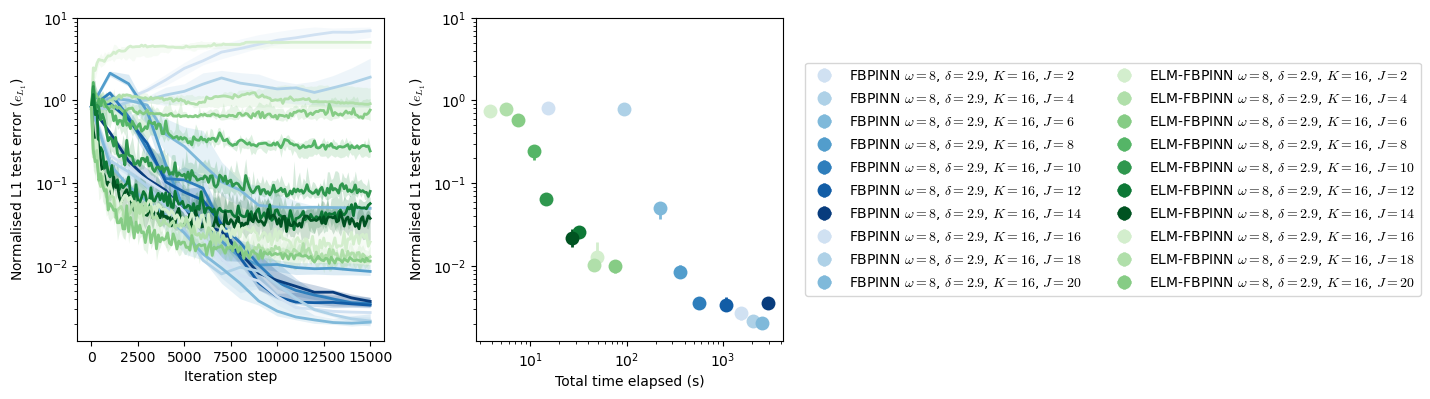

15000.0 (16, 5) PINN_n_hidden_units-8-omega_Helmholtz2D_FCN_2-layers_2-hidden_32-n_0.001-lr-4
15000.0 (16, 5) PINN_n_hidden_units-8-omega_Helmholtz2D_FCN_2-layers_4-hidden_48-n_0.001-lr-4
15000.0 (16, 5) PINN_n_hidden_units-8-omega_Helmholtz2D_FCN_2-layers_6-hidden_48-n_0.001-lr-4
15000.0 (16, 5) PINN_n_hidden_units-8-omega_Helmholtz2D_FCN_2-layers_8-hidden_48-n_0.001-lr-4
15000.0 (16, 5) PINN_n_hidden_units-8-omega_Helmholtz2D_FCN_2-layers_10-hidden_64-n_0.001-lr-4
15000.0 (16, 5) PINN_n_hidden_units-8-omega_Helmholtz2D_FCN_2-layers_12-hidden_64-n_0.001-lr-4
15000.0 (16, 5) PINN_n_hidden_units-8-omega_Helmholtz2D_FCN_2-layers_14-hidden_64-n_0.001-lr-4
15000.0 (16, 5) PINN_n_hidden_units-8-omega_Helmholtz2D_FCN_2-layers_16-hidden_80-n_0.001-lr-4
15000.0 (16, 5) PINN_n_hidden_units-8-omega_Helmholtz2D_FCN_2-layers_18-hidden_80-n_0.001-lr-4
15000.0 (16, 5) PINN_n_hidden_units-8-omega_Helmholtz2D_FCN_2-layers_20-hidden_80-n_0.001-lr-4
15000.0 (16, 5) FBPINN_n_hidden_units-8-omega_Helmholt

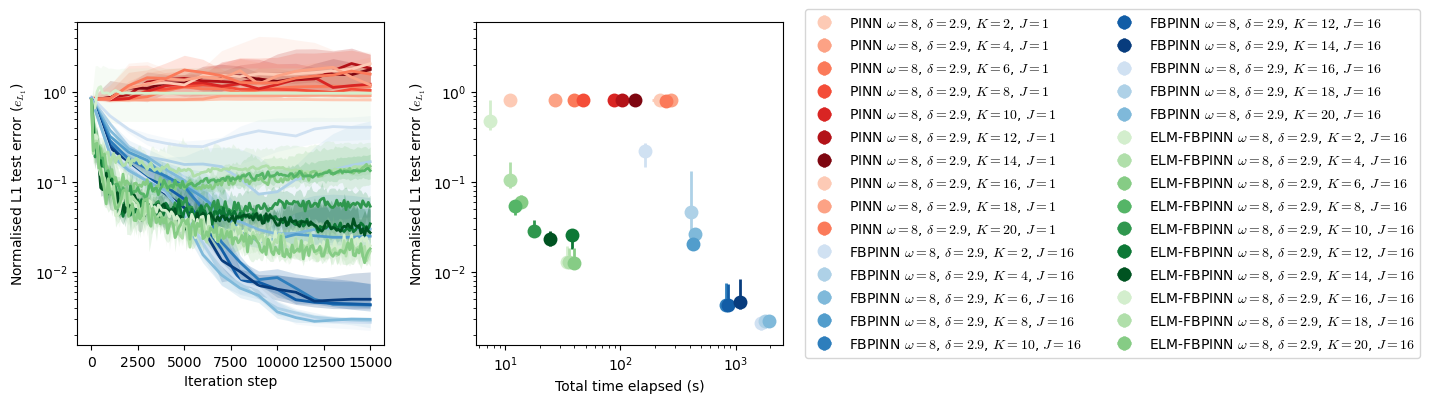

15000.0 (16, 5) FBPINN_n_subdomains_multiscale-4-omega_Helmholtz2D_FCN_[8]-levels_2.9-overlap_1-layers_16-hidden_40-n_0.001-lr-4
15000.0 (16, 5) FBPINN_n_subdomains_multiscale-6-omega_Helmholtz2D_FCN_[12]-levels_2.9-overlap_1-layers_16-hidden_60-n_0.001-lr-4
15000.0 (16, 5) FBPINN_n_subdomains_multiscale-8-omega_Helmholtz2D_FCN_[16]-levels_2.9-overlap_1-layers_16-hidden_80-n_0.001-lr-4
15000.0 (16, 5) FBPINN_n_subdomains_multiscale-10-omega_Helmholtz2D_FCN_[20]-levels_2.9-overlap_1-layers_16-hidden_100-n_0.001-lr-4
15000.0 (16, 5) FBPINN_n_subdomains_multiscale-12-omega_Helmholtz2D_FCN_[24]-levels_2.9-overlap_1-layers_16-hidden_120-n_0.001-lr-4
15000.0 (16, 5) FBPINN_n_subdomains_multiscale-14-omega_Helmholtz2D_FCN_[28]-levels_2.9-overlap_1-layers_16-hidden_140-n_0.001-lr-4
15000.0 (16, 5) FBPINN_n_subdomains_multiscale-16-omega_Helmholtz2D_FCN_[32]-levels_2.9-overlap_1-layers_16-hidden_160-n_0.001-lr-4
15000.0 (151, 5) ELMFBPINN_n_subdomains_multiscale-4-omega_1-R_HelmholtzELM2D_ELM_[

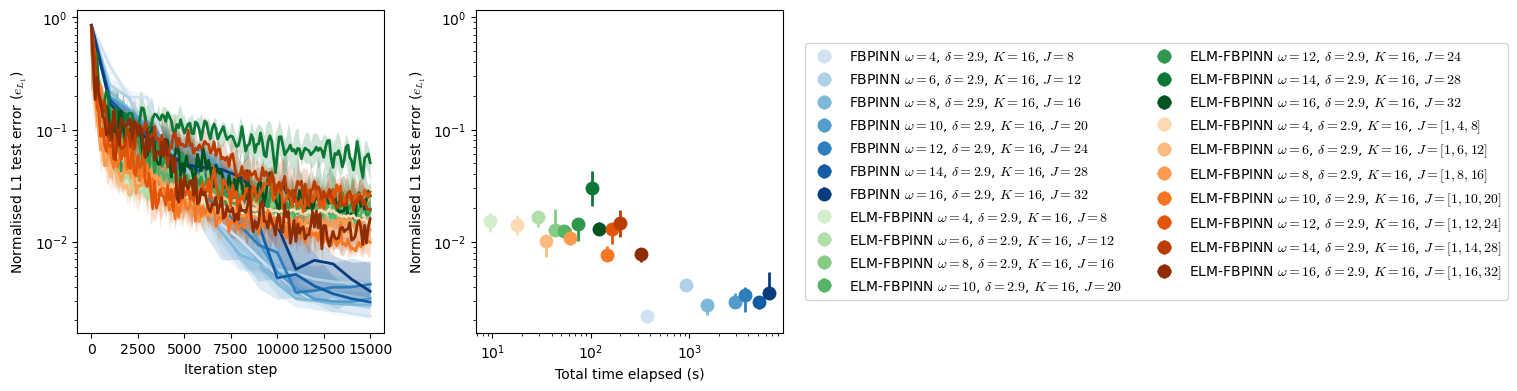

In [16]:
# FINAL TEST LOSS vs TIME (scaling)


# accuracy vs time [w0,overlap,dd,optimiser] (strong scaling & weak scaling) (weak scaling has solution plot from our solver)

for iw_deltas,tag2 in zip(
(
    [(iw, dict(J=v1, optimiser=v2, delta_name="n_subdomains")) for v2 in optimisers[1:] for (iw, v1) in enumerate(J_list)],
    [(iw, dict(C=v1, optimiser=v2, delta_name="n_hidden_units")) for v2 in optimisers for (iw, v1) in enumerate(C_list)],
    [(iw, dict(omega=v1, J=v2, optimiser=v3, level=v4, delta_name="n_subdomains_multiscale")) for (iw,v1,v2,v3,v4) in [

            # important: all scale n with J*C to keep M well-determined

            (0, 4, 8, optimisers[1], 1),# weak scaling with J
            (1, 6, 12, optimisers[1], 1),
            (2, 8, 16, optimisers[1], 1),
            (3, 10, 20, optimisers[1], 1),
            (4, 12, 24, optimisers[1], 1),
            (5, 14, 28, optimisers[1], 1),
            (6, 16, 32, optimisers[1], 1),

            (0, 4, 8, optimisers[2], 1),# weak scaling with J
            (1, 6, 12, optimisers[2], 1),
            (2, 8, 16, optimisers[2], 1),
            (3, 10, 20, optimisers[2], 1),
            (4, 12, 24, optimisers[2], 1),
            (5, 14, 28, optimisers[2], 1),
            (6, 16, 32, optimisers[2], 1),

            (0, 4, 8, optimisers[2], 3),# weak scaling with J
            (1, 6, 12, optimisers[2], 3),
            (2, 8, 16, optimisers[2], 3),
            (3, 10, 20, optimisers[2], 3),
            (4, 12, 24, optimisers[2], 3),
            (5, 14, 28, optimisers[2], 3),
            (6, 16, 32, optimisers[2], 3),
    ]],
), ["n-subdomains", "basis-functions", "weak"]):
    
    iws, deltas = zip(*iw_deltas)
    data = []
    for iw,config in zip(iws, apply_config_deltas(p0, deltas)[:-1]):# ignore p0 config at end of list
        (optimiser,optimiser_kwargs,run_fn) = config["optimiser"]
        network = config["network"]
        h,C,weight_scale = config["h"], config["C"], config["weight_scale"]
        omega,w,J = config["omega"], config["w"], config["J"]
        level = config["level"]
        delta_name = config["delta_name"]
    
        if run_fn == run_ELMFBPINN:
            problem=HelmholtzELM2D
        else:
            problem=Helmholtz2D
        if level > 1:
            l = [1] + [J // 2**k for k in range(level-2, 0, -1)] + [J]
        else:
            l = [J]
        ns = ((int(np.ceil(np.sqrt((C+1))))*J, int(np.ceil(np.sqrt((C+1))))*J),)
        if run_fn != run_ELMFBPINN:
            network = FCN
        if run_fn == run_PINN:
            if delta_name != "n_hidden_units":
                C = 64
            h = 2
        lr = 1e-3
        if run_fn == run_ELMFBPINN:
            tag = f"{delta_name}-{omega}-omega_{weight_scale}-R"
        else:
            tag = f"{delta_name}-{omega}-omega"
        
        # load models
        try:
            c, model, i, ts, l1s = loader[run_fn](tag, problem, network, l, w, h, C, ns, lr, n_seeds, optimiser, optimiser_kwargs, rootdir)
        except Exception as e:
            print(tc(e, "red"))
            continue
            
        # get plot entry
        J_ = 1 if run_fn == run_PINN else (l[0] if len(l)==1 else l)
        _, icolor = optimiser_label(optimiser, optimiser_kwargs, run_fn)
        if len(l)>1: icolor=1
        label = f"{run_label(run_fn)} $\\omega={omega}$, $\\delta={w}$, $K={C}$, $J={J_}$"
        data.append((label, icolor, iw%7, i, ts, l1s))
    
    
    plt.figure(figsize=0.7*np.array([13,6]))
    
    plt.subplot(1,2,1)
    for label, icolor, iw, i, ts, l1s in data:
        plot_l1(i, l1s, label=label, marker=None, color=colorss[icolor][iw], s=100, lw=2)
    fix_plot_convergence(legend=False)
    ylim = plt.ylim()
    mi = min([d[5][2].min() for d in data])# min l1n mi
    ylim=(max(mi/3,ylim[0]),min(ylim[1], 1e1))
    plt.ylim(ylim)
    
    plt.subplot(1,2,2)
    for label, icolor, iw, i, ts, l1s in data:
        scatter_l1(ts, l1s, label=label, marker="o", color=colorss[icolor][iw], s=10, lw=2)
    fix_plot_scaling()
    plt.legend(loc='center left', bbox_to_anchor=(1.05, 0.5),
               ncol=int(np.ceil(len(plt.gca().get_legend_handles_labels()[0]) / 16)))
    plt.ylim(ylim)
    
    plt.subplots_adjust(wspace=0.3)
    savefig(problem, f"{tag2}-scaling")
    plt.show()

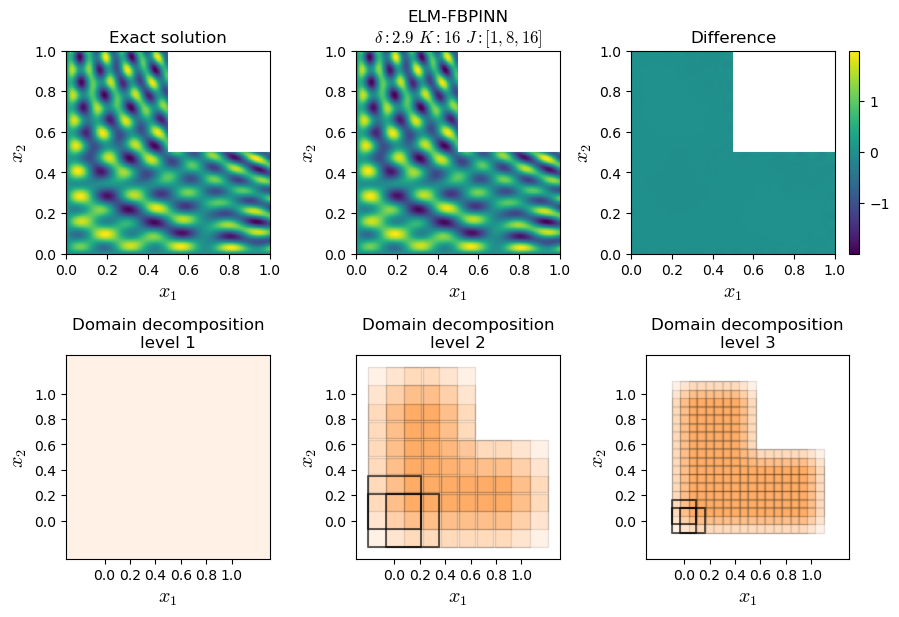

In [17]:
# BASE CASE PLOTS

(optimiser,optimiser_kwargs,run_fn) = p0["optimiser"]
network = p0["network"]
h,C,weight_scale = p0["h"], p0["C"], p0["weight_scale"]
omega,w,J = p0["omega"], p0["w"], p0["J"]
#level = p0["level"]
#delta_name = p0["delta_name"]
level = 3
delta_name = "decomposition_level"

tag = f"{delta_name}-{omega}-omega_{weight_scale}-R"
problem=HelmholtzELM2D
if level > 1:
    l = [1] + [J // 2**k for k in range(level-2, 0, -1)] + [J]
else:
    l = [J]
ns = ((int(np.ceil(np.sqrt((C+1))))*J, int(np.ceil(np.sqrt((C+1))))*J),)
n_test = (int(np.ceil(np.sqrt(30)))*J, int(np.ceil(np.sqrt(30)))*J)
lr=1e-3

c, model, i, t, l1n = load_ELMFBPINN_(tag, problem, network, l, w, h, C, ns, lr, seed, optimiser, optimiser_kwargs, rootdir)
label = f"{run_label(run_fn)}\n$\\delta:{w}$ $K:{C}$ $J:{l}$"

# get exact solution, masked on rectangular domain
all_params = model[1]
c.n_test = (150,150)
x_batch, tr = c.domain.sample_rectangle(all_params=all_params, key=None, sampler="grid", batch_shape=c.n_test)
u_exact = c.problem.exact_solution(all_params, x_batch, batch_shape=c.n_test).reshape(c.n_test)
active = jnp.ones((all_params["static"]["decomposition"]["m"]))
u = FBPINN_solution_(c, all_params, active, x_batch).reshape(c.n_test)
u_exact = u_exact.at[tr.reshape(c.n_test)].set(jnp.nan)
u = u.at[tr.reshape(c.n_test)].set(jnp.nan)

domain = c.domain
xmin, xmax = all_params["static"]["domain"]["xmin"], all_params["static"]["domain"]["xmax"]
xmins, xmaxs, wmins, wmaxs, *_ = all_params["static"]["decomposition"]["subdomain"]["params"]
pou = all_params["static"]["decomposition"]["subdomain"]["pou"]

# plot solution vs exact, domain decomposition, spectra

plt.figure(figsize=0.6*np.array([18.7,11]))

plt.subplot(2,3,1)
plt.title("Exact solution")
im = plt.imshow(u_exact.T, origin="lower", extent=(0,1,0,1))
fix_plot_2d_solution()
plt.xticks([0, 0.2, 0.4, 0.6, 0.8, 1])
plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1])

plt.subplot(2,3,2)
plt.title(label)
plt.imshow(u.T, origin="lower", extent=(0,1,0,1), vmin=im.get_clim()[0], vmax=im.get_clim()[1])
fix_plot_2d_solution()
plt.xticks([0, 0.2, 0.4, 0.6, 0.8, 1])
plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1])

plt.subplot(2,3,3)
plt.title("Difference")
plt.imshow((u_exact - u).T, origin="lower", extent=(0,1,0,1), vmin=im.get_clim()[0], vmax=im.get_clim()[1])
fix_plot_2d_solution()
plt.colorbar()
plt.xticks([0, 0.2, 0.4, 0.6, 0.8, 1])
plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1])

for l_ in range(level):
    xmins_ = xmins[pou[:,0]==l_]
    xmaxs_ = xmaxs[pou[:,0]==l_]
    
    plt.subplot(2,3,4+l_)
    plt.title(f"Domain decomposition\nlevel {l_+1}")
    patches, rs = [], []
    for i in range(len(xmins_)):
        patches.append(mpatches.Rectangle((xmins_[i,0],xmins_[i,1]),
                                           xmaxs_[i,0]-xmins_[i,0],
                                           xmaxs_[i,1]-xmins_[i,1],
                                         ))
        if i in [0,1,l[l_]]:
            rs.append(mpatches.Rectangle((xmins_[i,0],xmins_[i,1]),
                                          xmaxs_[i,0]-xmins_[i,0],
                                          xmaxs_[i,1]-xmins_[i,1],
                                         ))
    plt.gca().add_collection(mcoll.PatchCollection(patches,
                                                   alpha=0.1,
                                                   edgecolor="k",
                                                   facecolor="tab:orange"))
    plt.gca().add_collection(mcoll.PatchCollection(rs,
                                                   facecolor="none",
                                                   linewidth=1.5,
                                                   alpha=0.6,
                                                   edgecolor="k"))
    plt.xlim(-0.3, 1.3)
    plt.ylim(-0.3, 1.3)
    plt.xticks([0, 0.2, 0.4, 0.6, 0.8, 1])
    plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
    plt.xlabel("$x_1$", fontsize="x-large"); plt.ylabel("$x_2$", fontsize="x-large")
    plt.gca().set_aspect('equal')

plt.subplots_adjust(wspace=0, hspace=0.5)

savefig(problem, "solution")
plt.show()

# Weight scaling (across all problems)

15000.0 (151, 5) ELMFBPINN_weight_scaling-80-w0_0.125-R_HarmonicOscillatorELM1D_ELM_[20]-levels_2.9-overlap_1-layers_12-hidden_260-n_LinearSolver-least-squares-sps_lsqr-4
15000.0 (151, 5) ELMFBPINN_weight_scaling-80-w0_0.25-R_HarmonicOscillatorELM1D_ELM_[20]-levels_2.9-overlap_1-layers_12-hidden_260-n_LinearSolver-least-squares-sps_lsqr-4
15000.0 (151, 5) ELMFBPINN_weight_scaling-80-w0_0.5-R_HarmonicOscillatorELM1D_ELM_[20]-levels_2.9-overlap_1-layers_12-hidden_260-n_LinearSolver-least-squares-sps_lsqr-4
15000.0 (151, 5) ELMFBPINN_weight_scaling-80-w0_1-R_HarmonicOscillatorELM1D_ELM_[20]-levels_2.9-overlap_1-layers_12-hidden_260-n_LinearSolver-least-squares-sps_lsqr-4
15000.0 (151, 5) ELMFBPINN_weight_scaling-80-w0_2-R_HarmonicOscillatorELM1D_ELM_[20]-levels_2.9-overlap_1-layers_12-hidden_260-n_LinearSolver-least-squares-sps_lsqr-4
15000.0 (151, 5) ELMFBPINN_weight_scaling-80-w0_4-R_HarmonicOscillatorELM1D_ELM_[20]-levels_2.9-overlap_1-layers_12-hidden_260-n_LinearSolver-least-squares-

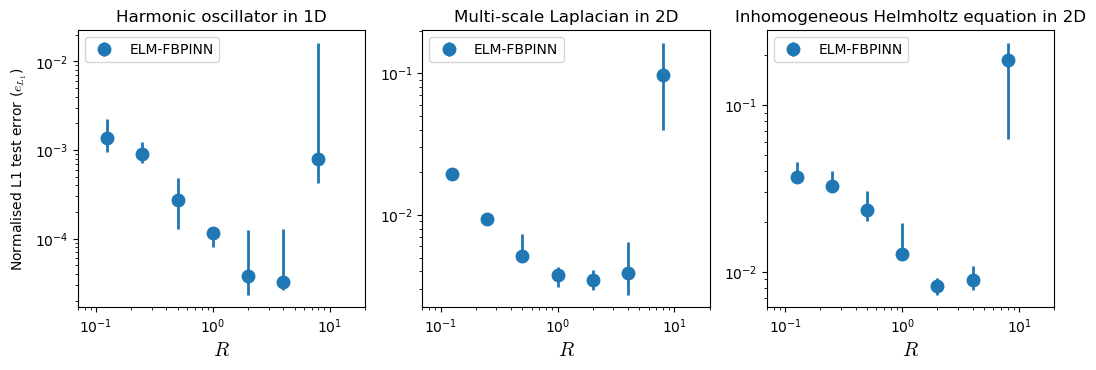

In [18]:
# WEIGHT SCALING COMPARISON

networks_ = [ELM]
deltas = [dict(weight_scale=v1, network=v2, delta_name="weight_scaling") for v1 in weight_scales for v2 in networks_]

datas = []
for ip,(p0, problem) in enumerate(zip([
dict(
    optimiser=optimisers[-1],
    network=ELM,
    h=1,
    C=12,
    weight_scale=1,
    w0=80,
    w=2.9,
    J=20,
    level=1,
    delta_name="weight_scaling",
    ),
dict(
    optimiser=optimisers[-1],
    network=ELM,
    h=1,
    C=16,
    weight_scale=1,
    w0=4,# rename n_omegas to match HO
    w=2.9,
    J=16,
    level=1,
    delta_name="weight_scaling",
    ),
dict(
    optimiser=optimisers[-1],
    network=ELM,
    h=1,
    C=16,
    weight_scale=1,
    w0=8,# rename omega to match HO
    w=2.9,
    J=16,
    level=1,
    delta_name="weight_scaling",
    ),
],
[
HarmonicOscillatorELM1D,
LaplaceELM2D_multiscale,
HelmholtzELM2D,
])):
    data = []
    for config in apply_config_deltas(p0, deltas):
        (optimiser,optimiser_kwargs,run_fn) = config["optimiser"]
        network = config["network"]
        h,C,weight_scale = config["h"], config["C"], config["weight_scale"]
        w0,w,J = config["w0"], config["w"], config["J"]
        level = config["level"]
        delta_name = config["delta_name"]
    
        l=[J]
        lr=1e-3
        if problem is HarmonicOscillatorELM1D:
            ns = (((C+1)*J,),)
            tag = f"{delta_name}-{w0}-w0_{weight_scale}-R"
        elif problem is LaplaceELM2D_multiscale:
            ns = ((int(np.ceil(np.sqrt((C+1))))*J, int(np.ceil(np.sqrt((C+1))))*J),)
            tag = f"{delta_name}-{w0}-n_omegas_{weight_scale}-R"
        elif problem is HelmholtzELM2D:
            ns = ((int(np.ceil(np.sqrt((C+1))))*J, int(np.ceil(np.sqrt((C+1))))*J),)
            tag = f"{delta_name}-{w0}-omega_{weight_scale}-R"
            
        # load models
        try:
            c, model, i, ts, l1s = load_ELMFBPINN_info(tag, problem, network, l, w, h, C, ns, lr, n_seeds, optimiser, optimiser_kwargs, rootdir)
        except Exception as e:
            print(tc(e, "red"))
            continue
        
        # get plot entry
        label = run_label(run_fn) if weight_scale == 1 else None
        color = colors[{k:i for i,k in enumerate(networks_)}[network]]
        data.append([problem_label(problem), weight_scale, l1s[-3:], color, label])
    datas.append(data)


# plot

plt.figure(figsize=0.6*np.array([3*7,6]))
for ip,data in enumerate(datas):
    plt.subplot(1,3,ip+1)
    for i,(title, weight_scale, (l1_min_me, l1_min_mi, l1_min_ma), color, label) in enumerate(data):
        plt.errorbar(weight_scale, l1_min_me, 
                     yerr=np.array([[l1_min_me-l1_min_mi],[l1_min_ma-l1_min_me]]),
                     ecolor=color,
                     marker="o",
                     markeredgecolor="none",
                     markerfacecolor=color,
                     label=label,
                     markersize=10,
                     lw=0,
                     elinewidth=2)
    plt.xlabel("$R$", fontsize="x-large")
    if ip == 0: plt.ylabel("Normalised L1 test error ($e_{L_1}$)")
    plt.legend(loc=2)
    plt.title(title)
    plt.yscale("log")
    plt.xscale("log")
    plt.xlim(7e-2, 2e1)
savefig(problem, "weight-scaling")
plt.show()